In [1]:
from IPython.core.display import display, HTML

display(HTML("<style>.container { width:90% !important; }</style>"))
#display(HTML("<style>.container { height:80% !important; }</style>"))
#display(HTML("<style>.output_wrapper, .output {height:auto; max-height:800px; width:auto; max-width:1350px;}</style>"))


<span style="color:red; font-size:32px; font-weight:bold">热点行业和热点概念-成分股-及龙一龙二龙三 </span> 

目的：  
1、单个概念找龙头  
2、过去N天找回流  

<span style="color:red; font-size:18px; font-weight:bold">牛市找龙头，龙头买不进去只能选补涨，电风扇行情熊市找潜伏…… </span> 

In [2]:
# 库
import jqdata
from jqdata import *
import datetime as dt
import time
import warnings

import numpy as np
import seaborn as sns
program_start_dt = dt.datetime.now()

import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

# 设置 Jupyter Notebook 的页面宽度
pd.set_option('display.width', 1200)        # 设置显示宽度
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.max_rows', None)


# 为了把代码迁移到聚宽回测环境中复用，
# 把全局变量定义为一个class，定义一个类和g.实例  
class a(): 
    pass
g=a()
context=a()

<span style="color:red; font-size:32px; font-weight:bold">指定本程序的参数 </span> 

In [3]:
#注意检查日期，特别是跨月要修改月份
#注意检查日期，特别是跨月要修改月份

g.auc_date = get_trade_days(count=10)[-1].strftime('%Y-%m-%d')
g.end_date = get_trade_days(count=10)[-2].strftime('%Y-%m-%d')
#g.end_date = '2024-10-28' # 最后一个完整K线数据日期
#g.auc_date = '2024-10-25' # 竞价日期，
g.watch_days = 7 #看多少天的热点概念，可以看11天；但因为大盘10月8号开始大跌，到10月16日共6个交易日，看看哪些不跌
g.remove_concept_with_more_than_N_stocks = 300 #其值为Fase或一个数值，比如200
    
if True: #只是为了少占屏幕显示区
    # 将日期格式标准化为 %Y-%m-%d; 比如将 '2024-9-6' 改为 '2024-09-06'
    g.end_date = dt.datetime.strptime(g.end_date, '%Y-%m-%d').strftime('%Y-%m-%d')
    g.auc_date = dt.datetime.strptime(g.auc_date, '%Y-%m-%d').strftime('%Y-%m-%d')
    print (f'将使用下列数据进行分析：')
    print (f'1、竞价日期         {g.auc_date}')
    print (f'2、K线最后一个交易日 {g.end_date}')
    print (f'3、观察{g.watch_days}天的数据')

将使用下列数据进行分析：
1、竞价日期         2024-12-09
2、K线最后一个交易日 2024-12-06
3、观察7天的数据


# 函数群

In [4]:
# 获取股票名称
def get_stock_name(stock_code):
    security_info = get_security_info(stock_code)
    if security_info is not None:
        return security_info.display_name
    else:
        print (f'接收到证券代码{stock_code}，get_stock_name找不到证券名字')
        return 'Unknown'  # Return a default name if the stock code is not found


# 行业和概念分析的代码写进了一个Python类

In [5]:
# 读取概念库 并 统计最热概念板块

# 分类热度统计，默认实现聚宽支持的行业分类，还有 同花顺 数据的概念分类
class Category:
    def __init__(self,industries_type='sw_l3'):
        warnings.filterwarnings('ignore')
        #g.WarningType.ShowWarning = False
        self.industries_type = industries_type
        self.industry_category = self.stock_industry(industries_type=industries_type)
        #概念库可以三选一：1同花顺概念；2同花顺行业和概念混合，也就是说把行业也当成概念；3聚宽概念库
        #同花顺的概念库比聚宽好，聚宽都没有跨境支付这个概念，而2024年10月11日跨境支付概念股票大涨
        #self.concept_category = self.stock_concepts_ths_20240831()
        self.concept_category = self.stock_concepts_and_industry_ths_20240928()
        #self.concept_category=self.stock_concepts_jq()

    #可以使用同花顺行业个概念混合而成的概念
    def stock_concepts_and_industry_ths_20240928(self, keep_concept_with_below_N_stocks=200):
        print('采用2024年12月9日同花顺行业和概念库，需每月更新一次')
        concept_stocks_file = 'cpt_ind_stocks_20240928.csv'
        concepts_file = 'cpt_ind_20240928.csv'

        # Step 1: 读取两个CSV文件
        concept_stocks = pd.read_csv(concept_stocks_file, encoding='utf-8')
        concepts = pd.read_csv(concepts_file, encoding='utf-8')

        # Step 2: 根据概念/行业代码获取对应的名称
        merged_df = concept_stocks.merge(concepts[['Unnamed: 0', 'name', 'type']], 
                                         left_on='index', right_on='Unnamed: 0', how='left')

        # 如果找不到对应的概念名或行业名，则设置为‘未知概念/行业’
        merged_df['name'].fillna('未知概念/行业', inplace=True)

        # Step 3: 修改股票代码后缀
        merged_df['stock'] = merged_df['stock'].str.replace('.SZ', '.XSHE', regex=False)
        merged_df['stock'] = merged_df['stock'].str.replace('.SH', '.XSHG', regex=False)

        # Step 4: 删除所有证券代码以8或4开头的行
        merged_df = merged_df[~merged_df['stock'].str.startswith(('8', '4', '68', '9'))]

        # Step 5: 找出type为C的概念，并统计其股票数量
        #concept_stock_counts = merged_df[merged_df['type'] == 'C']['name'].value_counts()

        # Step 6: 找出股票数量大于N的独特name概念
        #concepts_to_remove = concept_stock_counts[concept_stock_counts > keep_concept_with_below_N_stocks].index

        # Step 7: 删除这些概念对应的行
        #merged_df = merged_df[~merged_df['name'].isin(concepts_to_remove)]

        # Step 8: 构建最终的 DataFrame
        final_df = merged_df[['stock', 'name']]
        final_df.columns = ['code', 'category']  # 统一列名

        return final_df

    #可以使用同花顺概念
    def stock_concepts_ths_20240831(self, keep_concept_with_below_N_stocks=200):
        print ('采用同花顺股票概念库')
        """所有股票的同花顺概念列表"""
        # Step 1: 读取两个CSV文件
        concept_stocks_file = 'concept_stocks_20241209.csv'
        concepts_file = 'concepts_20241209.csv'

        # 读取concept_stocks和concepts数据
        concept_stocks = pd.read_csv(concept_stocks_file)
        concepts = pd.read_csv(concepts_file)

        # Step 2: 根据concept_stocks_20240831中的concept，获取concepts_20230831的concept_name
        # 如果找不到对应的概念名，则设置为‘未知概念’
        merged_df = concept_stocks.merge(concepts[['concept_thscode', 'concept_name']], 
                                         left_on='concept', right_on='concept_thscode', how='left')

        merged_df['concept_name'].fillna('未知概念', inplace=True)

        # Step 3: 修改股票代码后缀
        # SZ -> XSHE, SH -> XSHG
        merged_df['stock'] = merged_df['stock'].str.replace('.SZ', '.XSHE', regex=False)
        merged_df['stock'] = merged_df['stock'].str.replace('.SH', '.XSHG', regex=False)

        # Step 4: 统计每个概念对应的股票数量
        #concept_stock_counts = merged_df['concept_name'].value_counts()

        # Step 5: 找出股票数量大于N的概念
        #concepts_to_remove = concept_stock_counts[concept_stock_counts > keep_concept_with_below_N_stocks].index

        # Step 6: 删除这些概念对应的行
        #merged_df = merged_df[~merged_df['concept_name'].isin(concepts_to_remove)]

        # Step 7: 将合并后的数据放进df中
        df = merged_df[['stock', 'concept_name']]
        df.columns = ['code', 'category']  # 重命名列

        # 输出前几行查看数据
        df.head(10)
        return df
    
    #可以使用聚宽概念
    def stock_concepts_jq(self, keep_concept_with_below_N_stocks = 200):
        print ('采用聚宽股票概念库')
        """所有股票的聚宽概念列表"""
        q = query(jy.LC_ConceptList.ConceptCode, jy.LC_ConceptList.ConceptName)
        dict_concept = jy.run_query(q).set_index('ConceptCode')['ConceptName'].to_dict()
        stocks = jy.run_query(query(jy.SecuMain.InnerCode, jy.SecuMain.SecuCode).filter(jy.SecuMain.SecuCategory == 1,
                                                                                        jy.SecuMain.SecuMarket.in_(
                                                                                            [83, 90]),
                                                                                        jy.SecuMain.ListedState.in_(
                                                                                            [1])))
        s_code = stocks.set_index("InnerCode")['SecuCode']

        dfs = []
        min_id = 9953668143482
        while len(dfs) < 30 and min_id > 0:
            q = query(
                jy.LC_COConcept
            ).filter(jy.LC_COConcept.IndiState == 1, jy.LC_COConcept.ID < min_id).order_by(jy.LC_COConcept.ID.desc())
            df = jy.run_query(q)
            min_id = df.ID.min()
            if len(df) > 0:
                dfs.append(df)
            else:
                break
        df = pd.concat(dfs, ignore_index=True)

        sc = df.groupby('InnerCode').apply(
            lambda dx: ",".join([dict_concept[code] for code in dx.ConceptCode.unique()]))
        df_concept = pd.DataFrame({"concept": sc, 'code': s_code})
        df_concept['symbol'] = df_concept.code.map(normalize_code, na_action='ignore')
        s_concept = df_concept.dropna().set_index('symbol')['concept']
        df = pd.DataFrame(s_concept.str.split(',').tolist(), index=s_concept.index).stack()
        df = df.reset_index([0, 'symbol'])
        df.columns = ['code', 'category']

        # Step 5: 计算每个概念包含多少成分股
        #concept_stock_counts = df['category'].value_counts()

        # Step 6: 将成分股太多的概念删掉
        #concepts_to_remove = concept_stock_counts[concept_stock_counts > keep_concept_with_below_N_stocks].index
        #df = df[~df['category'].isin(concepts_to_remove)]
    
        return df


    def remove_category_with_stocks_more_than_N(self, N=300):
        """
        从 self.concept_category 中删除包含股票数量大于 N 的分类。

        :param N: 允许的最大股票数量，默认是 300。
        """
        # Step 1: 统计每个 category 中的股票数量
        category_counts = self.concept_category.groupby('category')['code'].nunique()

        # Step 2: 筛选出股票数量小于或等于 N 的分类
        valid_categories = category_counts[category_counts <= N].index

        # Step 3: 更新 self.concept_category，保留股票数量小于或等于 N 的分类行
        self.concept_category = self.concept_category[self.concept_category['category'].isin(valid_categories)]

    # 获取股票的行业代码
    def stock_industry(self,stocks_list=list(get_all_securities().index), industries_type="sw_l3"):
        stocks_industry_dict = get_industry(stocks_list)
        stocks_industry_df = pd.DataFrame(stocks_industry_dict).T[[industries_type]]
        stocks_industry_df[industries_type] = stocks_industry_df[industries_type].dropna().apply(
            lambda x: x['industry_name'])
        df_category = stocks_industry_df[[industries_type]].dropna().reset_index()
        df_category.columns = ['code', 'category']
        return df_category
    
    # 行业层级展示方法
    def industry_hierarchy(self, industries_type='sw_l3'):
        """
        展示行业的层级结构，默认为申万三级行业结构（sw_l3）。
        可以通过参数 industries_type 修改为其他层级。
        """
        # 获取股票列表
        stocks_list = list(get_all_securities().index)

        # 获取行业数据
        stocks_industry_dict = get_industry(stocks_list)
        
        # 将行业数据转换为 DataFrame
        df_industry = pd.DataFrame(stocks_industry_dict).T
        
        # 提取一级、二级和三级行业
        df_industry['一级行业'] = df_industry['sw_l1'].apply(lambda x: x['industry_name'] if pd.notna(x) else '未知')
        df_industry['二级行业'] = df_industry['sw_l2'].apply(lambda x: x['industry_name'] if pd.notna(x) else '未知')
        df_industry['三级行业'] = df_industry['sw_l3'].apply(lambda x: x['industry_name'] if pd.notna(x) else '未知')

        # 去除无效数据
        df_industry = df_industry[['一级行业', '二级行业', '三级行业']].dropna().drop_duplicates().reset_index(drop=True)

        return df_industry

    #先对个股打分：按日拉涨幅攻击超过9个点
    def score_by_return(self,stock_list=list(get_all_securities().index), return_days=1, return_filter=0.099,
                            end_dt=dt.datetime.now(), count=60, debug=False):

        """
        :param stock_list:  股票代码
        :param return_days: 收益率统计周期
        :param return_filter: 收益率阈值过滤
        :param end_date: 截止日期
        :param count: 查看的周期
        :return:
        """
        stock_list = [stock for stock in stock_list if stock[0] != '4' and stock[0] != '8' and stock[0] != '9' and stock[:2] != '68']
        close = get_price(stock_list, end_date=end_dt, count=count + return_days, fields=['close'], panel=True)[
            'close']

        if debug: 
            print(f'get_price获取{end_dt}的行情数据最后五行和最后五列(看看基于最后哪一天的数据来统计热点）：')
            print(close.iloc[-5:, -5:])

        df_return = (close / close.shift(return_days) - 1).iloc[return_days:]
        df_filter = (df_return > return_filter).astype(int)
        df_filter.index = df_return.index.strftime('%Y-%m-%d')
        return df_filter.T

    #先对个股打分：按日攻击超过9个点
    def score_by_attack(self, stock_list=list(get_all_securities().index), return_days=1, return_filter=0.099,
                        end_dt=dt.datetime.now(), count=60, debug=False):
        """
        :param stock_list: 股票代码
        :param return_days: 收益率统计周期
        :param return_filter: 收益率阈值过滤
        :param end_date: 截止日期
        :param count: 查看的周期
        :return:
        """
        stock_list = [stock for stock in stock_list if stock[0] != '4' and stock[0] != '8' and stock[0] != '9' and stock[:2] != '68']
        # 获取指定周期内的 pre_close 和 high 数据
        prices = get_price(stock_list, end_date=end_dt, count=count + return_days, fields=['pre_close', 'high'], panel=False)

        if debug:
            print(f'get_price获取{end_dt}的行情数据：')
            print(prices.head())  # 打印前几行以供调试

        # 计算是否满足攻击条件：high > (1 + return_filter) * pre_close
        prices['attack'] = (prices['high'] > (1 + return_filter) * prices['pre_close']).astype(int)

        # 格式化时间为字符串
        prices['time'] = prices['time'].dt.strftime('%Y-%m-%d')

        # 将数据透视为每只股票的攻击评分
        df_attack = prices.pivot(index='code', columns='time', values='attack')

        return df_attack
        
        
    def score_by_return_at_dt(self, stock_list=list(get_all_securities().index), return_days=1, return_filter=0.099,
                              end_dt=dt.datetime.now(), count=6, debug=False):
        """
        :param stock_list: 股票代码列表
        :param return_days: 收益率统计周期
        :param return_filter: 收益率阈值过滤
        :param end_dt: 结束日期和时间，可以精确到分钟
        :param count: 过去多少天的数据
        :return: 返回过滤后的收益率 DataFrame，行是股票代码，列是日期
        """

        stock_list = [stock for stock in stock_list if stock[0] != '4' and stock[0] != '8' and stock[0] != '9' and stock[:2] != '68']
        # 如果 end_dt 是字符串，先将其转换为 datetime 对象，默认时间为 23:59:59
        if isinstance(end_dt, str):
            try:
                end_dt = dt.datetime.strptime(end_dt, '%Y-%m-%d %H:%M:%S')
            except ValueError:
                # 如果没有提供时间部分，默认为 23:59:59
                end_dt = dt.datetime.strptime(end_dt, '%Y-%m-%d')
                end_dt = end_dt.replace(hour=23, minute=59, second=59)

        # 获取股票的日内数据，使用 get_bars 获取最近几天的数据，并限制日期范围
        dfb = get_bars(stock_list, count=count + return_days, unit='1d', fields=['date', 'close'],
                       include_now=True, end_dt=end_dt, fq_ref_date=dt.date.today(), df=True)

        # 将多维数据展开
        df_flattened = dfb.reset_index()

        # 重命名 level_0 列为 stock_code，删除 level_1 列
        df_flattened.rename(columns={'level_0': 'stock_code'}, inplace=True)
        df_flattened.drop(columns=['level_1'], inplace=True)

        # 过滤日期范围，保留最近的交易日数据
        recent_dates = df_flattened['date'].sort_values().unique()[-count:]  # 获取最近的日期
        df_flattened = df_flattened[df_flattened['date'].isin(recent_dates)]

        if debug: 
            print(f'get_bar获取{end_dt}的行情数据：')
            print(df_flattened.head(10))

        # 提取 close 列，计算收益率
        df_flattened['pct_change'] = df_flattened.groupby('stock_code')['close'].pct_change(return_days)

        # 过滤符合 return_filter 的数据，按日期为列，股票为行
        df_return = df_flattened.pivot(index='stock_code', columns='date', values='pct_change').iloc[return_days:]

        # 只保留日期部分，去掉时间部分
        df_return.columns = pd.to_datetime(df_return.columns).strftime('%Y-%m-%d')

        # 按 return_filter 进行打分，直接返回
        df_filter = (df_return > return_filter).astype(int)

        return df_filter


    # 先对个股打分：也可以按股票价格是否在N日均线上方；最终日期由end_date
    def score_by_bias(self,stock_list=list(get_all_securities().index), ma_len=20, end_date=dt.datetime.now(), count=510):
        """
        :param stock_list:
        :param ma_len:
        :param end_date:
        :param count:
        :return: index,2020-05-01
           000001.XSHE,         1
        """
        stock_list = [stock for stock in stock_list if stock[0] != '4' and stock[0] != '8' and stock[0] != '9' and stock[:2] != '68']
        close = get_price(stock_list, end_date=end_date, count=count + ma_len + 1, fields=['close'])['close']
        ma = close.rolling(ma_len).mean()
        return (close > ma).astype(int).iloc[-count:].T


    # 对概念板块打分，使用了对个股的打分作为输入；最终日期由df_score决定
    def category_score_and_pct_attacking(self, df_score, df_category=None, count=60, daily_top_filter=30, top_N=10):
        """
        计算分类的得分和成分股数量，以及涨幅超过某个阈值的股票比例，并生成每日攻击最多的分类排名表格。
        :param df_score: 股票得分，格式为 (code,2015-01-01,2015-01-02...)
        :param df_category: 股票分类，格式为 (code,category)
        :param count: 查看最近周期（热度在这个周期的排行），默认 30 天
        :param daily_top_filter: 只保留每天得分前 N 的分类，默认 30
        :param top_N: 每天显示攻击家数最多的前 N 个分类，默认为 10
        :return: DataFrame，包含 'category', 'date', 'score', 'stock_count', 'pct_of_attack'
        """

        # Step 1: 构建股票代码到分类的映射
        code_category_dict = df_category.groupby('code').apply(lambda dx: list(dx['category'].unique())).to_dict()
        dats = df_score.columns

        # 统计分类得分
        dat_cat_dict = {}  # {'2020-05-01': {'光伏概念': 30, '连板': 50}}
        for i in range(0, len(dats)):
            codes = list(df_score[df_score[dats[i]] > 0].index)
            s_score = df_score[dats[i]]
            category_count_dict = {}  # 每天初始化一个空的 category_count_dict

            # 针对当天的股票，累计每个分类的得分
            for code in codes:
                if code in code_category_dict:
                    categories = code_category_dict[code]
                    for category in categories:
                        if category not in category_count_dict:
                            category_count_dict[category] = float(s_score[code])
                        else:
                            category_count_dict[category] += float(s_score[code])

            dat_cat_dict[dats[i]] = category_count_dict

        # 构建 DataFrame，格式 index: 日期, columns: 分类, values: 得分
        df_category_score = pd.DataFrame.from_dict(dat_cat_dict, orient='index').fillna(0).tail(count).T

        # 计算成分股数量，即每个分类的股票总数
        stock_count_dict = df_category.groupby('category')['code'].nunique().to_dict()

        # Step 2: 遍历所有日期，计算 pct_of_attack 和 score
        all_results = []
        total_days = len(df_category_score.columns)  # 总的处理天数

        for index, date in enumerate(df_category_score.columns):
            pct_of_attack_dict = {}

            for category in df_category_score.index:
                score = df_category_score.at[category, date]
                stock_count = stock_count_dict.get(category, 1)  # 防止出现除以 0 的情况
                pct_of_attack = 100 * score / stock_count if stock_count > 0 else 0
                pct_of_attack_dict[category] = round(pct_of_attack, 2)

            # 将每天的结果添加到列表
            df_daily = pd.DataFrame({
                'category': df_category_score.index,
                'date': date,
                'score': df_category_score[date].values,
                'stock_count': [stock_count_dict.get(category, 0) for category in df_category_score.index],
                'pct_of_attack': [pct_of_attack_dict.get(category, 0) for category in df_category_score.index]
            })

            # 保留每天得分前 daily_top_filter 的分类
            df_daily = df_daily.sort_values(by='score', ascending=False).head(daily_top_filter)
            all_results.append(df_daily)

        # Step 3: 将每天的结果拼接为一个完整的 DataFrame
        df_attack = pd.concat(all_results, ignore_index=True)

        return df_attack

    # 对行业板块打分，使用了对个股的打分作为输入；最终日期由df_score决定
    def industry_score_and_pct_attacking(self, df_score, count=60, daily_top_filter=30, top_N=10, level=2):
        """
        计算申万行业不同层级（一级、二级、三级）的得分和成分股数量，以及涨幅超过某个阈值的股票比例，
        并生成每日攻击最多的行业排名表格。
        :param df_score: 股票得分，格式为 (code,2015-01-01,2015-01-02...)
        :param count: 查看最近周期（热度在这个周期的排行），默认 30 天
        :param daily_top_filter: 只保留每天得分前 N 的行业，默认 30
        :param top_N: 每天显示攻击家数最多的前 N 个行业，默认为 10
        :param level: 统计的行业层级，1表示一级行业，2表示二级行业，3表示三级行业，默认为2
        :return: DataFrame，包含 'industry', 'date', 'score', 'stock_count', 'pct_of_attack'
        """

        # 根据 level 参数选择不同的申万行业层级
        industry_level = {1: 'sw_l1', 2: 'sw_l2', 3: 'sw_l3'}
        selected_industry = industry_level.get(level, 'sw_l2')  # 默认为二级行业

        # 获取行业分类数据
        df_category = self.stock_industry(industries_type=selected_industry)

        # Step 1: 构建股票代码到行业的映射
        code_category_dict = df_category.groupby('code').apply(lambda dx: list(dx['category'].unique())).to_dict()
        dats = df_score.columns

        # 统计行业得分
        dat_cat_dict = {}
        for i in range(0, len(dats)):
            codes = list(df_score[df_score[dats[i]] > 0].index)
            s_score = df_score[dats[i]]
            category_count_dict = {}  # 每天初始化一个空的 category_count_dict

            # 针对当天的股票，累计每个行业的得分
            for code in codes:
                if code in code_category_dict:
                    categories = code_category_dict[code]
                    for category in categories:
                        if category not in category_count_dict:
                            category_count_dict[category] = float(s_score[code])
                        else:
                            category_count_dict[category] += float(s_score[code])
            dat_cat_dict[dats[i]] = category_count_dict

        # 构建 DataFrame，格式 index: 日期, columns: 行业, values: 得分
        df_category_score = pd.DataFrame.from_dict(dat_cat_dict, orient='index').fillna(0).tail(count).T

        # 计算成分股数量，即每个行业的股票总数
        stock_count_dict = df_category.groupby('category')['code'].nunique().to_dict()

        # Step 2: 遍历所有日期，计算 pct_of_attack 和 score
        all_results = []
        total_days = len(df_category_score.columns)

        for index, date in enumerate(df_category_score.columns):
            pct_of_attack_dict = {}

            for category in df_category_score.index:
                score = df_category_score.at[category, date]
                stock_count = stock_count_dict.get(category, 1)
                pct_of_attack = 100 * score / stock_count if stock_count > 0 else 0
                pct_of_attack_dict[category] = round(pct_of_attack, 2)

            df_daily = pd.DataFrame({
                'category': df_category_score.index,
                'date': date,
                'score': df_category_score[date].values,
                'stock_count': [stock_count_dict.get(category, 0) for category in df_category_score.index],
                'pct_of_attack': [pct_of_attack_dict.get(category, 0) for category in df_category_score.index]
            })

            df_daily = df_daily.sort_values(by='score', ascending=False).head(daily_top_filter)
            all_results.append(df_daily)

        df_attack = pd.concat(all_results, ignore_index=True)

        return df_attack

    def industry_money_flow(self, end_date=dt.datetime.now(), count=10, top_N=10, level=1):
        """
        分析行业的资金流动情况，包括全量资金和大资金的对比，并添加一级、二级、三级行业名称。
        :param end_date: 数据截止日期，默认为当前时间，支持字符串和 datetime 格式
        :param count: 观察的天数
        :param top_N: 选取资金流入/流出最多的前N个行业
        :param level: 选择行业层级，1为一级行业，2为二级行业，3为三级行业，默认为1
        :return: DataFrame，包含 'category', 'date', 'net_amount_main', 'total_money', 'avg_big_money_per_stock',
                 'avg_total_money_per_stock', 'big_money_to_total_money_abs_ratio', 'big_money_vs_total_money_diff', 'stock_count'
        """

        # Step 1: 如果 end_date 是字符串，转换为 datetime 对象
        if isinstance(end_date, str):
            end_date = dt.datetime.strptime(end_date, "%Y-%m-%d")

        # Step 2: 获取行业的股票列表，确保代码唯一
        industry_category_df = self.stock_industry(industries_type={1: 'sw_l1', 2: 'sw_l2', 3: 'sw_l3'}.get(level, 'sw_l2'))
        stock_list = industry_category_df['code'].unique()  # 获取股票列表

        # 获取资金流动数据，传递 end_date 和 count 参数
        money_flow_df = get_money_flow(stock_list, end_date=end_date, 
                                       fields=['sec_code', 'date', 'net_amount_main', 'net_amount_xl', 
                                               'net_amount_l', 'net_amount_m', 'net_amount_s'], 
                                       count=count)

        # 转换 sec_code 为 code 并匹配行业
        money_flow_df['code'] = money_flow_df['sec_code']

        # 将行业分类信息与资金流数据合并
        money_flow_df = money_flow_df.merge(industry_category_df[['code', 'category']], on='code', how='left')

        # Step 3: 汇总全量资金流（使用特大、大、中、小资金的合计）
        money_flow_df['total_money'] = money_flow_df[['net_amount_xl', 'net_amount_l', 'net_amount_m', 'net_amount_s']].sum(axis=1)

        # 汇总成分股数量，确保匹配 'category'
        stock_count_df = industry_category_df.groupby('category')['code'].nunique().reset_index()
        stock_count_df.columns = ['category', 'stock_count']

        # Step 4: 汇总到概念/行业层级的每日大资金流与全量资金流
        daily_money_flow = money_flow_df.groupby(['category', 'date']).agg({
            'net_amount_main': 'sum',
            'total_money': 'sum'
        }).reset_index()

        # Step 5: 计算每个行业的成分股数量，合并到汇总后的数据
        daily_money_flow = daily_money_flow.merge(stock_count_df, on='category', how='left')

        # Step 6: 计算平均每只股票的大资金和总资金
        daily_money_flow['avg_big_money_per_stock'] = daily_money_flow.apply(
            lambda row: row['net_amount_main'] / row['stock_count'] if row['stock_count'] > 0 else 0, axis=1
        )
        daily_money_flow['avg_total_money_per_stock'] = daily_money_flow.apply(
            lambda row: row['total_money'] / row['stock_count'] if row['stock_count'] > 0 else 0, axis=1
        )

        # Step 7: 计算大资金与总资金绝对值的比值（可能是拉升信号）
        daily_money_flow['big_money_to_total_money_abs_ratio'] = daily_money_flow['net_amount_main'] / daily_money_flow['total_money'].abs()

        # Step 8: 计算大资金与总资金的差值（可能是出货信号）
        daily_money_flow['big_money_vs_total_money_diff'] = daily_money_flow['net_amount_main'] - daily_money_flow['total_money']

        # Step 9: 按照总资金流进行排序，选取前N名行业
        top_industries = daily_money_flow.groupby('category').agg({'total_money': 'sum'}).sort_values(by='total_money', ascending=False).head(top_N).index
        top_money_flow = daily_money_flow[daily_money_flow['category'].isin(top_industries)]

        # Step 10: 返回与 category_money_flow 一致的结构
        return top_money_flow[['category', 'date', 'stock_count', 'net_amount_main', 'total_money', 
                               'avg_big_money_per_stock', 'avg_total_money_per_stock', 
                               'big_money_to_total_money_abs_ratio', 'big_money_vs_total_money_diff']]


    def category_money_flow(self, end_date=dt.datetime.now(), count=10, top_N=10):
        """
        统计所有概念板块的每日资金流数据，包括成分股数量、大资金、总资金、平均每只股票的大资金、平均每只股票的总资金、
        大资金与总资金绝对值的比值、大资金与总资金的差值等，按天统计。

        并检查是否由于某些股票在某些日期没有资金数据，如果是，则发出告警。

        :param end_date: 资金流动数据的截止日期，默认为当前日期
        :param count: 统计的天数，默认10天
        :param top_N: 选取前N个概念板块
        :return: DataFrame，包含每日统计结果
        """

        # Step 1: 如果 end_date 是字符串，转换为 datetime 对象
        if isinstance(end_date, str):
            end_date = dt.datetime.strptime(end_date, "%Y-%m-%d")

        # Step 2: 获取所有股票的列表
        stock_list = list(self.concept_category['code'].unique())

        # Step 3: 使用 get_money_flow 获取资金流数据，按指定日期范围获取
        money_flow_df = get_money_flow(stock_list, end_date=end_date, 
                                       fields=['sec_code', 'date', 'net_amount_main', 'net_amount_xl', 
                                               'net_amount_l', 'net_amount_m', 'net_amount_s'], 
                                       count=count)

        # Step 4: 转换 sec_code 为 code，并匹配概念分类
        money_flow_df['code'] = money_flow_df['sec_code']
        money_flow_df = money_flow_df.merge(self.concept_category[['code', 'category']], on='code', how='left')

        # Step 5: 计算总资金（包含不同大小的资金）
        money_flow_df['total_money'] = money_flow_df[['net_amount_xl', 'net_amount_l', 'net_amount_m', 'net_amount_s']].sum(axis=1)

        # Step 6: 统计每个概念板块的成分股数量
        stock_count = self.concept_category.groupby('category')['code'].nunique().to_dict()

        # Step 7: 检查每只股票在不同日期的资金数据，发出告警
        missing_data_warning = money_flow_df[money_flow_df[['net_amount_main', 'total_money']].isnull().any(axis=1)]
        if not missing_data_warning.empty:
            for index, row in missing_data_warning.iterrows():
                print(f"告警：股票 {row['code']} 在 {row['date']} 没有资金数据，可能已停盘或无交易记录。")

        # Step 8: 按日期和概念板块汇总大资金和总资金
        df_summary = money_flow_df.groupby(['category', 'date']).agg({
            'net_amount_main': 'sum',   # 大资金
            'total_money': 'sum'        # 总资金
        }).reset_index()

        # Step 9: 计算平均每只股票的大资金和总资金
        df_summary['avg_big_money_per_stock'] = df_summary.apply(lambda row: row['net_amount_main'] / stock_count.get(row['category'], 1), axis=1)
        df_summary['avg_total_money_per_stock'] = df_summary.apply(lambda row: row['total_money'] / stock_count.get(row['category'], 1), axis=1)

        # Step 10: 计算大资金与总资金绝对值的比值（可能是拉升信号）
        df_summary['big_money_to_total_money_abs_ratio'] = df_summary['net_amount_main'] / df_summary['total_money'].abs()

        # Step 11: 计算大资金与总资金的差值（可能是出货信号）
        df_summary['big_money_vs_total_money_diff'] = df_summary['net_amount_main'] - df_summary['total_money']

        # Step 12: 添加成分股数量
        df_summary['stock_count'] = df_summary['category'].map(stock_count)

        # Step 13: 按照总资金流进行排序，选取前N名概念板块
        top_categories = df_summary.groupby('category').agg({'total_money': 'sum'}).sort_values(by='total_money', ascending=False).head(top_N).index
        top_money_flow = df_summary[df_summary['category'].isin(top_categories)]

        # Step 14: 返回完整的每日统计结果 DataFrame
        return top_money_flow[['category', 'date', 'stock_count', 'net_amount_main', 'total_money', 
                               'avg_big_money_per_stock', 'avg_total_money_per_stock', 
                               'big_money_to_total_money_abs_ratio', 'big_money_vs_total_money_diff']]

    # 构建攻击次数排名表格
    def construct_category_rank_table(self, df_final, top_N=10):
        """
        构建一个表格，横坐标是日期，纵坐标是排名，从上到下依次填充当天攻击次数最多的category名字，同时展示成分股数量和攻击比例。
        :param df_final: DataFrame，包含 'category', 'date', 'score', 'stock_count', 'pct_of_attack'
        :param top_N: 每天显示攻击家数最多的前N个category
        :return: ranked_table, 包含每个格子的category名字, 成分股数和攻击比例的表格
        """
        # 创建一个包含 'category', 'date', 'stock_count', 'pct_of_attack' 的列
        df_final['combined_info'] = df_final.apply(
            lambda row: f"{row['category']} ({row['stock_count']}只, {row['pct_of_attack']}%攻击)", axis=1
        )

        # Pivot the data to construct the table, 通过 'combined_info' 替换 'score'
        category_rank_table = df_final.pivot_table(index='category', columns='date', values='combined_info', aggfunc='first')

        # Sort each day's categories by 'score' 并得到前 N 个分类
        ranked_table = pd.DataFrame()
        for date in category_rank_table.columns:
            top_categories = df_final[df_final['date'] == date].sort_values(by='score', ascending=False).head(top_N)
            ranked_table[date] = top_categories['combined_info'].values

        # Add ranking index (1-N)
        ranked_table.index = range(1, top_N + 1)

        # Return the ranked table with combined information
        return ranked_table

    def find_categories_by_words(self, words):
        """
        根据不完整的关键词筛选并打印包含该关键词的唯一分类列表
        :param words: 字符串，筛选的关键词（如 '国企'）
        :return: 无返回值，直接打印结果
        """
        # 假设 self.concept_category 是一个 DataFrame，包含 'category' 列
        if hasattr(self, 'concept_category') and 'category' in self.concept_category.columns:
            # 使用str.contains筛选包含给定关键词的分类
            matching_categories = self.concept_category[self.concept_category['category'].str.contains(words, na=False)]['category']

            # 获取唯一的分类列表
            unique_categories = matching_categories.unique()

            # 打印唯一分类列表
            print(f"包含'{words}'的概念分类有：")
            for category in unique_categories:
                print(category)
        else:
            print("分类数据不存在或格式不正确")

    # 通过概念查找相关股票
    def find_stocks_by_category(self, category_value, fuzzy_match=True):
        """
        查找包含指定概念的所有股票代码
        :param category_value: 要查找的概念名称
        :param fuzzy_match: 是否启用模糊匹配，默认开启
        :return: 包含该概念的所有股票代码的列表
        """
        
        # 确保概念数据已正确加载
        category_df = self.concept_category
        
        if category_df is None or category_df.empty:
            raise ValueError("概念数据未正确加载，请检查 self.concept_category")
        
        # 根据 fuzzy_match 决定是否进行模糊匹配
        if fuzzy_match:
            # 模糊匹配概念名称
            filtered_df = category_df[category_df['category'].str.contains(category_value, case=False, na=False)]
        else:
            # 精确匹配
            filtered_df = category_df[category_df['category'] == category_value]
        
        # 检查是否找到匹配的成分股
        if filtered_df.empty:
            print(f"未找到概念 '{category_value}' 的成分股，可能是概念名称不正确或不在数据中。")
            return []
        
        # 返回成分股代码的唯一列表
        return filtered_df['code'].unique().tolist()


    def find_stocks_by_industry(self, industry_name, fuzzy_match=True):
        """
        根据行业名称查找包含该行业的所有成分股代码。
        支持模糊匹配行业名称。

        :param industry_name: 行业名称
        :param fuzzy_match: 是否启用模糊匹配，默认开启
        :return: 包含该行业成分股代码的列表
        """

        # 获取一级、二级和三级行业名称的 DataFrame
        industry_df_l1 = self.stock_industry(industries_type='sw_l1')  # 一级行业
        industry_df_l2 = self.stock_industry(industries_type='sw_l2')  # 二级行业
        industry_df_l3 = self.stock_industry(industries_type='sw_l3')  # 三级行业

        # 合并一级、二级、三级行业的 DataFrame
        industry_df = pd.concat([industry_df_l1, industry_df_l2, industry_df_l3])

        # 检查 industry_df 是否正确加载
        if industry_df.empty:
            raise ValueError("行业数据未正确加载，请检查 industry_category")

        # 根据 fuzzy_match 的值来决定模糊匹配还是精确匹配
        if fuzzy_match:
            # 使用 str.contains 进行模糊匹配行业名称
            filtered_df = industry_df[industry_df['category'].str.contains(industry_name, case=False, na=False)]
        else:
            # 精确匹配
            filtered_df = industry_df[industry_df['category'] == industry_name]

        # 检查是否找到了匹配的成分股
        if filtered_df.empty:
            print(f"未找到行业 '{industry_name}' 的成分股，可能是行业名称不正确或不在数据中。")
            return []

        # 返回成分股代码的唯一列表
        return filtered_df['code'].unique().tolist()


    
    def get_stock_count_and_avg_change_of_a_category(self, concept, count=30):
        """
        计算指定概念的股票数量、平均涨幅、涨幅超过9%的股票数量及其占比
        :param concept: 目标概念（如'国企改革'）
        :param count: 查看最近周期，默认值为30
        :return: DataFrame，包含 'category', 'date', 'count', 'avg_change', 'count_of_attack', 'pct_of_attack'
        """
        # 筛选指定概念的股票
        if hasattr(self, 'concept_category') and 'category' in self.concept_category.columns:
            # 获取属于指定概念的股票代码
            concept_stocks = self.concept_category[self.concept_category['category'] == concept]['code'].unique()

            # 确保股票代码格式正确
            def format_stock_code(code):
                if code.endswith('.XSHG') or code.endswith('.XSHE'):
                    return code  # 如果已经有后缀，不做任何操作
                elif code.startswith('60'):
                    return code + '.XSHG'
                elif code.startswith('00') or code.startswith('30'):
                    return code + '.XSHE'
                return code

            # 格式化股票代码，确保有正确的后缀
            concept_stocks_formatted = [format_stock_code(code) for code in concept_stocks]

            # 使用 get_price 获取指定股票在最近 count 天的行情数据
            try:
                # 获取股票的收盘价
                close_prices = get_price(concept_stocks_formatted, end_date=dt.datetime.now(), count=count + 1, fields=['close'], panel=True)['close']

                # 计算每个股票每日的涨幅
                df_return = (close_prices / close_prices.shift(1) - 1).iloc[1:]

                # 检查 df_return.index 是否是日期格式，如果不是则转换为日期格式
                if not isinstance(df_return.index, pd.DatetimeIndex):
                    df_return.index = pd.to_datetime(df_return.index)

                # 计算每日有数据的股票数量
                stock_counts = df_return.notna().sum(axis=1)

                # 计算每日涨幅超过 9% 的股票数量
                count_of_attack = (df_return > 0.09).sum(axis=1)

                # 计算每日的平均涨幅，忽略 NaN
                avg_changes = df_return.mean(axis=1, skipna=True)

                # 计算涨幅超过 9% 的股票占比
                pct_of_attack = (count_of_attack / stock_counts * 100).round(2)

                # 构建结果 DataFrame
                df_result = pd.DataFrame({
                    'date': df_return.index.strftime('%Y-%m-%d'),  # 确保 date 是字符串格式
                    'count': stock_counts.values,
                    'avg_change': avg_changes.values,
                    'count_of_attack': count_of_attack.values,
                    'pct_of_attack': pct_of_attack.values
                })

                # 添加 'category' 列
                df_result['category'] = concept

                # 返回最终结果
                return df_result[['category', 'date', 'count', 'avg_change', 'count_of_attack', 'pct_of_attack']]
            except Exception as e:
                print(f"行情数据获取失败: {e}")
                return pd.DataFrame()

        else:
            print("分类数据不存在或格式不正确")
            return pd.DataFrame()

    def get_top_N_days_by_avg_change(self, concept, days=1200, N=10):
        """
        找到指定概念在过去 n 天内涨幅最大的五天，并打印出日期
        :param concept: 目标概念（如'白酒概念'）
        :param days: 查找的周期，默认为1200天
        """
        # 获取指定概念在过去 n 天内的股票数量和平均涨幅
        df_concept = self.get_stock_count_and_avg_change_of_a_category(concept, count=days)

        if df_concept.empty:
            print(f"没有找到 {concept} 的数据")
            return

        # 对 avg_change 进行降序排序，找到涨幅最大的五天
        top_N_days = df_concept.sort_values(by='avg_change', ascending=False).head(N)

        # 打印日期和涨幅
        print(f"{concept} 在过去 {days} 天内涨幅最大的五天：")
        for index, row in top_N_days.iterrows():
            print(f"日期: {row['date']}, 涨幅: {row['avg_change']:.2%}")
        
        return top_N_days.copy()
    
    def lead_stocks_in_category(self, category_value, end_date=dt.datetime.now(), watch_days=60, top_N=10, fuzzy_match=True, draw_chart=True):
        """
        找出指定板块中攻击次数最多的股票，并画出这些股票的绝对收益变化曲线和板块攻击股票占比曲线。
        只返回按攻击次数排序的股票列表。
        """
        # 1. 找到指定板块中的所有股票
        if not fuzzy_match:
            # 严格搜索，category 必须严格等于 category_value
            concept_stocks = self.concept_category[self.concept_category['category'] == category_value]['code'].unique()
        else:
            # 模糊搜索，category 包含 category_value
            concept_stocks = self.concept_category[self.concept_category['category'].str.contains(category_value)]['code'].unique()

        # 确保股票代码格式正确
        concept_stocks = [
            code if code.endswith('.XSHG') or code.endswith('.XSHE') 
            else (code + '.XSHG' if code.startswith('6') else code + '.XSHE')
            for code in concept_stocks
        ]

        # 检查是否找到了任何符合条件的股票
        if len(concept_stocks) == 0:
            print(f"没有找到属于 {category_value} 的股票（模糊搜索：{fuzzy_match}）")
            return []

        # 2. 获取这些股票在 watch_days 内的收盘价数据，计算每日涨幅和攻击次数
        try:
            close_prices = get_price(concept_stocks, end_date=end_date, count=watch_days + 1, fields=['close'], panel=True)['close']
        except Exception as e:
            print(f"获取价格数据时发生错误: {e}")
            return []

        if close_prices.empty:
            print("警告：没有获取到有效的价格数据，请检查输入参数！")
            return []

        # 使用前向填充来填补 NaN 值，并用 0 填充仍然存在的 NaN 值
        close_prices = close_prices.fillna(method='ffill').fillna(0)

        # 计算每日涨幅和攻击次数
        df_return = (close_prices / close_prices.shift(1) - 1).iloc[1:]  # 计算每日涨幅
        df_attack = (df_return > 0.09).astype(int)  # 判断是否达到攻击阈值（涨幅>9%）

        # 跳过所有 df_return 和 df_attack 中为空的股票
        valid_stocks = df_return.columns[df_return.notna().any()].tolist()
        df_return = df_return[valid_stocks]
        df_attack = df_attack[valid_stocks]

        if df_return.empty:
            print("警告：所有股票都没有有效的涨幅数据，请检查是否是刚上市的股票。")
            return []

        # 3. 统计每只股票的攻击次数，并按攻击次数降序排列，取前 top_N 只股票
        attack_counts = df_attack.sum(axis=0).sort_values(ascending=False).head(top_N)
        lead_stocks_by_attack = attack_counts.index

        # 4. 创建图形，并绘制按累计收益排序的 top_N 只股票的每日绝对收益变化曲线
        import matplotlib.pyplot as plt

        # 创建一个字典来存储每只股票的累计收益
        stock_cumulative_returns = {}

        # 计算每只股票在 watch_days 时间段内的累计收益
        for stock in lead_stocks_by_attack:
            stock_cumulative_return = close_prices[stock].pct_change().cumsum().iloc[-watch_days:]
            stock_cumulative_returns[stock] = stock_cumulative_return.iloc[-1]  # 累计收益的最终值

        # 5. 按累计收益排序
        sorted_stocks_by_return = sorted(stock_cumulative_returns.items(), key=lambda x: x[1], reverse=True)

        if draw_chart: 
            # 创建图形并绘制数据
            fig, ax = plt.subplots(figsize=(12, 6))

            lines = []  # 用于存储绘制的线条，用于创建 legend
            labels_by_return = []  # 按累计收益排序的标签

            for stock, _ in sorted_stocks_by_return:
                stock_name = get_stock_name(stock)
                stock_return = close_prices[stock].pct_change().cumsum().iloc[-watch_days:]
                line, = ax.plot(stock_return.index, stock_return.values, label=f'{stock} ({stock_name})')

                lines.append(line)
                labels_by_return.append(f'{stock} ({stock_name})')  # 累计收益排序标签

            # 创建按累计收益排序的 legend
            ax.legend(lines, labels_by_return, title='按累计收益排序', loc='upper left', bbox_to_anchor=(1.05, 1))

            # 设置图表标题和标签
            ax.set_title(f'概念板块 {category_value} 中累计收益最多的{top_N}只股票')
            ax.set_xlabel('Date')
            ax.set_ylabel('累计收益')
            ax.grid(True)

            # 显示图表
            plt.tight_layout()
            try:
                plt.show()
            except Exception as e:
                print(f"绘制图表时发生错误: {e}")

        # 返回按攻击次数排序的股票列表
        return list(lead_stocks_by_attack)


    def lead_stocks_in_category_with_K_line(self, category_value, end_date=dt.datetime.now(), watch_days=60, top_N=10, fuzzy_match=True):
        """
        找出指定板块中攻击次数最多的股票，并画出这些股票的 K 线图和板块攻击股票占比曲线
        """
        # 找到指定板块中的所有股票
        if not fuzzy_match:
            concept_stocks = self.concept_category[self.concept_category['category'] == category_value]['code'].unique()
        else:
            concept_stocks = self.concept_category[self.concept_category['category'].str.contains(category_value)]['code'].unique()

        concept_stocks = [
            code if code.endswith('.XSHG') or code.endswith('.XSHE') 
            else (code + '.XSHG' if code.startswith('6') else code + '.XSHE')
            for code in concept_stocks
        ]

        if len(concept_stocks) == 0:
            print(f"没有找到属于 {category_value} 的股票（模糊搜索：{fuzzy_match}）")
            return

        daily_prices = get_price(concept_stocks, end_date=end_date, count=watch_days + 1, 
                                 fields=['open', 'close', 'high', 'low', 'high_limit', 'volume'], panel=True)

        open_prices = daily_prices['open']
        close_prices = daily_prices['close']
        high_prices = daily_prices['high']
        low_prices = daily_prices['low']

        df_return = (close_prices / close_prices.shift(1) - 1).iloc[1:]  # 计算每日涨幅
        df_attack = (df_return > 0.09).astype(int)  # 判断是否达到攻击阈值（涨幅>9%）

        attack_counts = df_attack.sum(axis=0).sort_values(ascending=False).head(top_N)
        lead_stocks = attack_counts.index

        # 定义自定义颜色方案：涨为绿色，跌为红色
        mc = mpf.make_marketcolors(up='green', down='red', edge='inherit', wick='inherit', volume='inherit')

        # 定义自定义风格
        s = mpf.make_mpf_style(marketcolors=mc)

        for stock in lead_stocks:
            stock_name = get_stock_name(stock)
            stock_data = pd.DataFrame({
                'open': open_prices[stock],
                'high': high_prices[stock],
                'low': low_prices[stock],
                'close': close_prices[stock],
                'volume': daily_prices['volume'][stock]
            })
            stock_data.index = pd.to_datetime(stock_data.index)

            # 使用 mplfinance 绘制 K 线图，并使用自定义颜色样式
            mpf.plot(stock_data, type='candle', style=s, title=f'{stock_name} ({stock}) - K Line',
                     ylabel='Price', volume=True, mav=(5, 10), show_nontrading=False, figsize=(12, 6))

        # 在最后恢复 matplotlib 的默认字体和样式
        # 恢复到默认的字体和样式
        plt.rcParams.update(plt.rcParamsDefault)


In [6]:
# 初始化：按概念分类的实例
category=Category()
print ("初始化结束")

#为所有股票代码取得名字
category.concept_category['name'] = category.concept_category['code'].apply(get_stock_name)

# 删除 'name' 列为 'Unknown' 的行
category.concept_category = category.concept_category[category.concept_category['name'] != 'Unknown']

# 确认删除后的结果
category.concept_category.reset_index(drop=True, inplace=True)
print("已删除找不到证券名字的股票代码")


采用2024年12月9日同花顺行业和概念库，需每月更新一次
初始化结束
已删除找不到证券名字的股票代码


In [7]:
# 剔除不重要的概念：
categories_to_drop = [
    '标普道琼斯中国','富时罗素','MSCI','CIPS概念','ST','st', 
    '融资融券','融券','融资' 
    '微盘股','专精特新','区块链','数字经济',
    '注册制次新股','新股与次新股',
    #'央企国企改革','国企改革','破净股',
    '低价股','可转债',
    #'沪股通','深股通',
    '昨日涨停','昨日连板','昨日首板','昨日触板',
    '科创企业同股同权',
    '一带一路',
    '北京冬奥会', '房价上涨',     
    '广东','浙江','上海','江苏','深圳','北京'
]

category.concept_category = category.concept_category[~category.concept_category['category'].isin(categories_to_drop)]

# 创建正则表达式，匹配所有需要删除的关键词
pattern = '|'.join([f'.*{word}.*' for word in categories_to_drop])

# 使用模糊匹配删除包含这些关键词的所有概念
category.concept_category = category.concept_category[~category.concept_category['category'].str.contains(pattern, na=False)]

#删掉成分股超过200的概念
if g.remove_concept_with_more_than_N_stocks: category.remove_category_with_stocks_more_than_N(N=g.remove_concept_with_more_than_N_stocks)

In [8]:
print(f'测试某个股票包含的概念')
print(category.concept_category[category.concept_category['code'] == '600657.XSHG'])

测试某个股票包含的概念
              code    category  name
7059   600657.XSHG  债转股(AMC概念)  信达地产
12817  600657.XSHG        参股保险  信达地产
30318  600657.XSHG        物业管理  信达地产
40456  600657.XSHG        证金持股  信达地产
46576  600657.XSHG         房地产  信达地产
49413  600657.XSHG        住宅开发  信达地产


In [9]:
print(f"测试某个概念包含的股票{len(category.concept_category[category.concept_category['category'] == '证金持股'])}")

测试某个概念包含的股票206


In [10]:
#通过概念关键词找出完整的概念名字：
category.find_categories_by_words('光刻')

包含'光刻'的概念分类有：
光刻机
光刻胶


In [11]:
#通过概念关键词找出完整的成分股
print (len( category.find_stocks_by_category('光刻机', fuzzy_match=True) ))

23


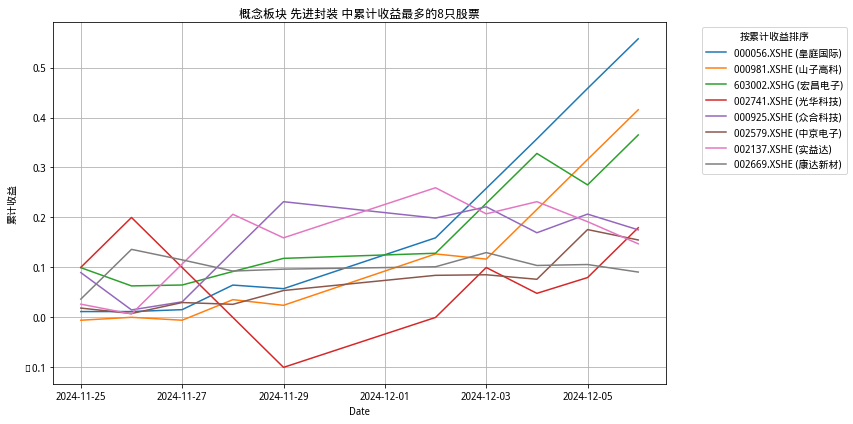

['000056.XSHE',
 '002741.XSHE',
 '000981.XSHE',
 '603002.XSHG',
 '002137.XSHE',
 '000925.XSHE',
 '002579.XSHE',
 '002669.XSHE']

In [12]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('先进封装', end_date=g.end_date, watch_days=10, top_N=8)

# 先对个股打分

In [13]:
# 三选一：用什么时候的 攻击个股数据，来统计热点概念？

# 1、用 “g.end_date上一个交易日”的热点、热点来预测当日热点。看很多天之前的，应该用选项1，否则会使用未来数据。
#df_stock_score  = category.score_by_return(return_days=1,return_filter=0.09,end_dt = g.end_date,count=g.watch_days,debug=True)

# 2、用 g.auc_date 当日的竞价数据的热点、热点来预测当日热点，当天运行本程序会一直变。竞价结束时9点25-30分运行，看看用的是什么？
# 事后用选项2看之前某一天的早盘热点是不对的，因为get_price取了g.auc_date 的全天数据，来预测当天盘中的表现 —— 未来数据。 但当天盘中应该用选项2。
df_stock_score  = category.score_by_return(return_days=1,return_filter=0.09,end_dt = g.end_date,count=g.watch_days,debug=True)

# 3、用某个时间点来：比如看盘后。比如午间。
# 注意：score_by_return_at_dt 用的是get_bar，指定 2024-09-30 09:25:00 是不行的，因为没有 bar，比如在9：30之后 
#the_end_dt = g.auc_date + ' 09:30:00'  # ！！！太滞后，不合适的 ！！！
#df_stock_score = category.score_by_return_at_dt(return_days=1, return_filter=0.095, end_dt=the_end_dt, count=g.watch_days, debug=True)

#print(df_stock_score.columns)  # 检查列索引结构
#print(df_stock_score.head(10))  # 检查列索引结构

get_price获取2024-12-06的行情数据最后五行和最后五列(看看基于最后哪一天的数据来统计热点）：
            605580.XSHG  605588.XSHG  605589.XSHG  605598.XSHG  605599.XSHG
2024-12-02         9.98        47.70        24.79        21.77        11.61
2024-12-03        10.14        47.59        24.63        20.98        11.43
2024-12-04         9.97        48.18        24.09        20.42        11.25
2024-12-05        10.34        47.07        24.29        20.48        11.26
2024-12-06        10.92        46.34        24.12        20.60        11.36


# 热点转移到了什么行业？

In [14]:
print (f"\033[1;31m 一级行业打分。更确切地说：先对个股打分；然后按概念成分股统计，得到哪些行业比较热 \033[0m ：")

# 按 概念成分股关系和个股的分数，统计概念板块的分数 
df_industry_score  = category.industry_score_and_pct_attacking(df_score=df_stock_score, count=g.watch_days, daily_top_filter=10, top_N=5, level=1)

# 将 带有score的概念板块的分数交给 construct_category_rank_table 呈现出来
df_industry_score_rank_table = category.construct_category_rank_table(df_final = df_industry_score, top_N=5) 
df_industry_score_rank_table

 一级行业打分。更确切地说：先对个股打分；然后按概念成分股统计，得到哪些行业比较热  ：


,2024-11-28,2024-11-29,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06
1,"化工I (395只, 2.53%攻击)","机械设备I (523只, 4.97%攻击)","机械设备I (523只, 4.4%攻击)","机械设备I (523只, 4.4%攻击)","机械设备I (523只, 4.78%攻击)","机械设备I (523只, 4.97%攻击)","机械设备I (523只, 3.44%攻击)"
2,"商业贸易I (100只, 9.0%攻击)","计算机I (337只, 4.15%攻击)","汽车I (268只, 5.97%攻击)","计算机I (337只, 3.26%攻击)","汽车I (268只, 4.48%攻击)","汽车I (268只, 5.97%攻击)","传媒I (130只, 13.08%攻击)"
3,"电子I (456只, 1.75%攻击)","汽车I (268只, 5.22%攻击)","传媒I (130只, 9.23%攻击)","汽车I (268只, 3.36%攻击)","商业贸易I (100只, 5.0%攻击)","计算机I (337只, 4.75%攻击)","计算机I (337只, 4.15%攻击)"
4,"机械设备I (523只, 1.34%攻击)","商业贸易I (100只, 14.0%攻击)","化工I (395只, 3.04%攻击)","建筑装饰I (159只, 5.03%攻击)","电子I (456只, 1.1%攻击)","传媒I (130只, 10.0%攻击)","建筑装饰I (159只, 8.18%攻击)"
5,"纺织服装I (104只, 6.73%攻击)","食品饮料I (123只, 10.57%攻击)","纺织服装I (104只, 10.58%攻击)","电子I (456只, 1.54%攻击)","食品饮料I (123只, 3.25%攻击)","建筑装饰I (159只, 5.03%攻击)","汽车I (268只, 2.61%攻击)"


# 热点转移到了什么概念？

In [15]:
print (f"\033[1;31m 概念打分。更确切地说：先对个股打分；然后按概念成分股统计，得到哪些概念比较热\033[0m ：")


# 按 概念成分股关系和个股的分数，统计概念板块的分数 
df_category_score  = category.category_score_and_pct_attacking(df_score=df_stock_score, df_category=category.concept_category, count=g.watch_days, daily_top_filter=10)  

# 将 带有score的概念板块的分数交给 construct_category_rank_table 呈现出来
df_category_money_flow_rank_table = category.construct_category_rank_table(df_final = df_category_score, top_N=5) 
df_category_money_flow_rank_table

 概念打分。更确切地说：先对个股打分；然后按概念成分股统计，得到哪些概念比较热 ：


,2024-11-28,2024-11-29,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06
1,"网络直播 (195只, 9.23%攻击)","跨境电商 (214只, 10.75%攻击)","跨境电商 (214只, 14.02%攻击)","乡村振兴 (287只, 5.23%攻击)","通用设备 (187只, 8.02%攻击)","AIGC概念 (154只, 14.29%攻击)","乡村振兴 (287只, 6.62%攻击)"
2,"跨境电商 (214只, 7.94%攻击)","工业互联网 (268只, 7.84%攻击)","海南自贸区 (28只, 78.57%攻击)","网络直播 (195只, 6.67%攻击)","高端装备 (230只, 5.22%攻击)","抖音概念 (128只, 14.84%攻击)","文化传媒概念 (186只, 10.22%攻击)"
3,"乡村振兴 (287只, 5.23%攻击)","网络直播 (195只, 10.26%攻击)","乡村振兴 (287只, 7.32%攻击)","跨境电商 (214只, 6.07%攻击)","风电 (295只, 3.73%攻击)","文化传媒概念 (186只, 10.22%攻击)","文化传媒 (86只, 17.44%攻击)"
4,"文化传媒概念 (186只, 6.45%攻击)","新型工业化 (161只, 11.18%攻击)","网络直播 (195只, 10.77%攻击)","工业互联网 (268只, 4.48%攻击)","工业互联网 (268只, 4.1%攻击)","通用设备 (187只, 9.63%攻击)","数据要素 (227只, 6.61%攻击)"
5,"节能环保 (279只, 3.94%攻击)","人形机器人 (56只, 30.36%攻击)","文化传媒概念 (186只, 10.75%攻击)","通用设备 (187只, 6.42%攻击)","减速器 (87只, 12.64%攻击)","腾讯概念 (157只, 11.46%攻击)","新型城镇化 (180只, 7.78%攻击)"


In [16]:
# 按 每个概念 攻击股 的比例（而不是绝对数量） 排序 看看？ 
# 复制 df_category_score 到 df_category_score_by_pct_attacking
df_category_score_by_pct_attacking = df_category_score.copy()

# 将 pct_of_attack 列赋值给 score 列
df_category_score_by_pct_attacking['score'] = df_category_score_by_pct_attacking['pct_of_attack']

# 调用 construct_category_rank_table 方法，按攻击比例生成表格
df_category_money_flow_rank_table_by_pct_attacking = category.construct_category_rank_table(df_final=df_category_score_by_pct_attacking, top_N=5)

# 显示表格
df_category_money_flow_rank_table_by_pct_attacking


,2024-11-28,2024-11-29,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06
1,"网络直播 (195只, 9.23%攻击)","人形机器人 (56只, 30.36%攻击)","海南自贸区 (28只, 78.57%攻击)","元宇宙 (159只, 6.92%攻击)","减速器 (87只, 12.64%攻击)","抖音概念 (128只, 14.84%攻击)","文化传媒 (86只, 17.44%攻击)"
2,"跨境电商 (214只, 7.94%攻击)","减速器 (87只, 16.09%攻击)","网红经济 (92只, 16.3%攻击)","网络直播 (195只, 6.67%攻击)","预制菜 (101只, 9.9%攻击)","AIGC概念 (154只, 14.29%攻击)","虚拟数字人 (112只, 10.71%攻击)"
3,"抖音概念 (128只, 7.81%攻击)","新型工业化 (161只, 11.18%攻击)","跨境电商 (214只, 14.02%攻击)","通用设备 (187只, 6.42%攻击)","通用设备 (187只, 8.02%攻击)","虚拟数字人 (112只, 14.29%攻击)","ChatGPT概念 (113只, 10.62%攻击)"
4,"文化传媒概念 (186只, 6.45%攻击)","跨境电商 (214只, 10.75%攻击)","抖音概念 (128只, 13.28%攻击)","腾讯概念 (157只, 6.37%攻击)","智能物流 (130只, 6.92%攻击)","腾讯概念 (157只, 11.46%攻击)","文化传媒概念 (186只, 10.22%攻击)"
5,"腾讯概念 (157只, 5.73%攻击)","网络直播 (195只, 10.26%攻击)","网络直播 (195只, 10.77%攻击)","跨境电商 (214只, 6.07%攻击)","高端装备 (230只, 5.22%攻击)","元宇宙 (159只, 10.69%攻击)","AIGC概念 (154只, 8.44%攻击)"


In [17]:
# 最后一天的热点概念，单独看看
last_day = df_category_score_by_pct_attacking['date'].max()
df_last_day_category_score = df_category_score[df_category_score['date'] == last_day]   
df_last_day_category_score_sorted = df_last_day_category_score.sort_values(by='pct_of_attack', ascending=False)
df_last_day_category_score_sorted

,category,date,score,stock_count,pct_of_attack,combined_info
62,文化传媒,2024-12-06,15.00,86,17.44,"文化传媒 (86只, 17.44%攻击)"
68,虚拟数字人,2024-12-06,12.00,112,10.71,"虚拟数字人 (112只, 10.71%攻击)"
69,ChatGPT概念,2024-12-06,12.00,113,10.62,"ChatGPT概念 (113只, 10.62%攻击)"
61,文化传媒概念,2024-12-06,19.00,186,10.22,"文化传媒概念 (186只, 10.22%攻击)"
67,AIGC概念,2024-12-06,13.00,154,8.44,"AIGC概念 (154只, 8.44%攻击)"
66,百度概念,2024-12-06,14.00,169,8.28,"百度概念 (169只, 8.28%攻击)"
64,新型城镇化,2024-12-06,14.00,180,7.78,"新型城镇化 (180只, 7.78%攻击)"
65,通用设备,2024-12-06,14.00,187,7.49,"通用设备 (187只, 7.49%攻击)"
60,乡村振兴,2024-12-06,19.00,287,6.62,"乡村振兴 (287只, 6.62%攻击)"
63,数据要素,2024-12-06,15.00,227,6.61,"数据要素 (227只, 6.61%攻击)"


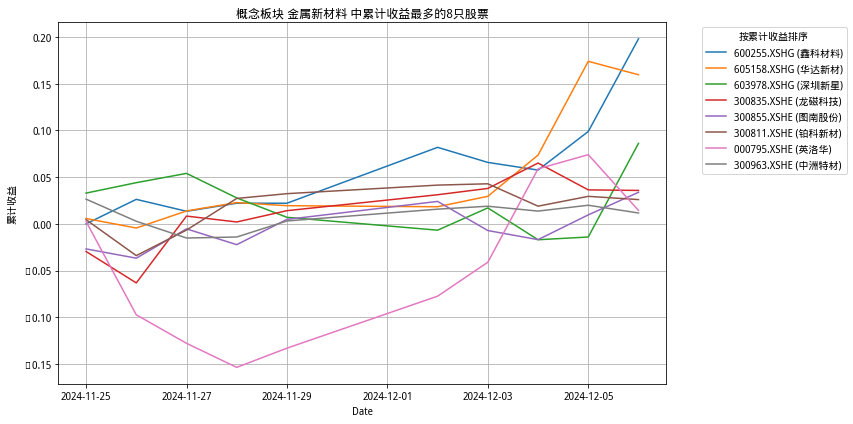

['605158.XSHG',
 '600255.XSHG',
 '603978.XSHG',
 '000795.XSHE',
 '300963.XSHE',
 '300835.XSHE',
 '300855.XSHE',
 '300811.XSHE']

In [18]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('金属新材料', end_date=g.end_date, watch_days=10, top_N=8)

# 在相同行业或概念里找补涨

# 从行业里找

In [19]:
# 行业搜索：拷贝上面的热点行业，粘贴到这里来搜索， 最热行业 的成分股
stocks_in_hot_industry = category.find_stocks_by_industry('国企改革', fuzzy_match=True)
print(f"最热行业 的 成分股{len(stocks_in_hot_industry)}只: {len(stocks_in_hot_industry)}；太多了，如需打印，去掉下面的注释符号# ")
#for stock in stocks_in_hot_industry: print (stock, get_stock_name(stock))

未找到行业 '国企改革' 的成分股，可能是行业名称不正确或不在数据中。
最热行业 的 成分股0只: 0；太多了，如需打印，去掉下面的注释符号# 


# 从概念里找

In [20]:
# 概念搜索：拷贝上面的热点概念，粘贴到这里来搜索， 最热概念 的成分股
stocks_in_hot_concept = category.find_stocks_by_category('房地产', fuzzy_match=True)
print(f"最热概念 的 成分股{len(stocks_in_hot_concept)}只；太多了，如需打印，去掉下面的注释符号# ")
#for stock in stocks_in_hot_concept: print (stock, get_stock_name(stock))

最热概念 的 成分股98只；太多了，如需打印，去掉下面的注释符号# 


# 手工做拼接：并集 或 交集

In [21]:
hot_stocks_intersection = list(set(stocks_in_hot_industry).intersection(set(stocks_in_hot_concept)))
print(f"最热行业 和 最热 概念成分股 交集: {hot_stocks_intersection}只")
for stock in hot_stocks_intersection: print (stock + get_stock_name(stock))

最热行业 和 最热 概念成分股 交集: []只


In [22]:
hot_stocks_union = list(set(stocks_in_hot_industry).union(set(stocks_in_hot_concept)))
print(f"最热行业 和 最热 概念成分股 的 并集: {len(hot_stocks_union)}只，太多了，如需打印，去掉下面的注释符号#")
#for stock in hot_stocks_union: print (stock + get_stock_name(stock))

最热行业 和 最热 概念成分股 的 并集: 98只，太多了，如需打印，去掉下面的注释符号#


# 自动做个拼接：热点行业 和 热点概念 并集

In [23]:
def get_hot_industry_stocks(df_industry_score, category):
    # 找出最后一天分数最高的行业
    last_day = df_industry_score['date'].max()
    
    # 按照最后一天的行业得分进行排序，找到最热的行业
    hottest_industry = df_industry_score[df_industry_score['date'] == last_day].sort_values(by='score', ascending=False).iloc[0]['category']
    
    # 使用 category.find_stocks_by_industry 找到最热行业的成分股
    industry_stocks = category.find_stocks_by_industry(hottest_industry, fuzzy_match=True)

    print(f"最后一天最热行业是: {hottest_industry}, 成分股为: {len(industry_stocks)}只")
    return industry_stocks

def get_hot_category_stocks(df_category_score, concept_category_df):
    # 找出最后一天分数最高的概念
    last_day = df_category_score['date'].max()

    # 按照最后一天的概念得分进行排序，找到最热的概念
    hottest_category_by_attack_count = df_category_score[df_category_score['date'] == last_day].sort_values(by='score', ascending=False).iloc[0]['category']
    # 根据概念名称在 concept_category_df 中找到成分股
    stocks_in_hottest_category_by_attack_count = concept_category_df[concept_category_df['category'] == hottest_category_by_attack_count]['code'].unique().tolist()
    print(f"最后一天按涨停攻击家数最热概念是: {hottest_category_by_attack_count}, 成分股为: {len(stocks_in_hottest_category_by_attack_count)}只")

    # 按照最后一天的概念得分进行排序，找到最热的概念
    hottest_category_by_attack_pct = df_category_score[df_category_score['date'] == last_day].sort_values(by='pct_of_attack', ascending=False).iloc[0]['category']
    # 根据概念名称在 concept_category_df 中找到成分股
    stocks_in_hottest_category_by_attack_pct = concept_category_df[concept_category_df['category'] == hottest_category_by_attack_pct]['code'].unique().tolist()
    print(f"最后一天按涨停攻击比例最热概念是: {hottest_category_by_attack_pct}, 成分股为: {len(stocks_in_hottest_category_by_attack_pct)}只")
    
    # 合并最热概念的成分股
    category_stocks = list(set(stocks_in_hottest_category_by_attack_count).union(set(stocks_in_hottest_category_by_attack_pct)))
    print(f"两个维度的最热概念成分股合并起来: 成分股为: {len(category_stocks)}只")

    return category_stocks


def get_combined_stocks(df_industry_score, df_category_score, category):
    # 获取最热行业的成分股
    industry_stocks = get_hot_industry_stocks(df_industry_score, category)
    
    # 获取最热概念的成分股
    category_stocks = get_hot_category_stocks(df_category_score, category.concept_category)

    # 求成分股的并集
    combined_stocks = set(industry_stocks).union(set(category_stocks))

    print(f"最后一天 热点行业 和 热点概念 成分股的并集为: {len(combined_stocks)}只")
    return list(combined_stocks)

# 获取最热行业和最热概念的成分股并集
hot_stocks = get_combined_stocks(df_industry_score, df_category_score, category)

print(f"太多了，如需打印，去掉下面的注释符号#")
#for stock in hot_stocks: print (stock + get_stock_name(stock))


最后一天最热行业是: 机械设备I, 成分股为: 523只
最后一天按涨停攻击家数最热概念是: 乡村振兴, 成分股为: 287只
最后一天按涨停攻击比例最热概念是: 文化传媒, 成分股为: 86只
两个维度的最热概念成分股合并起来: 成分股为: 365只
最后一天 热点行业 和 热点概念 成分股的并集为: 869只
太多了，如需打印，去掉下面的注释符号#


# 聚焦龙头？除了龙一、其实也是补涨吧

In [24]:
#个股看几天？
N_days = 20

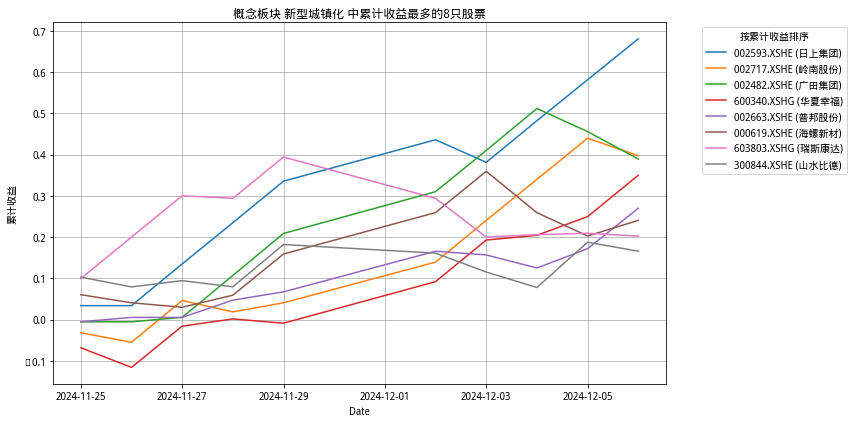

['002593.XSHE',
 '002717.XSHE',
 '002482.XSHE',
 '600340.XSHG',
 '603803.XSHG',
 '000619.XSHE',
 '300844.XSHE',
 '002663.XSHE']

In [25]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('新型城镇化', end_date=g.end_date, watch_days=10, top_N=8)

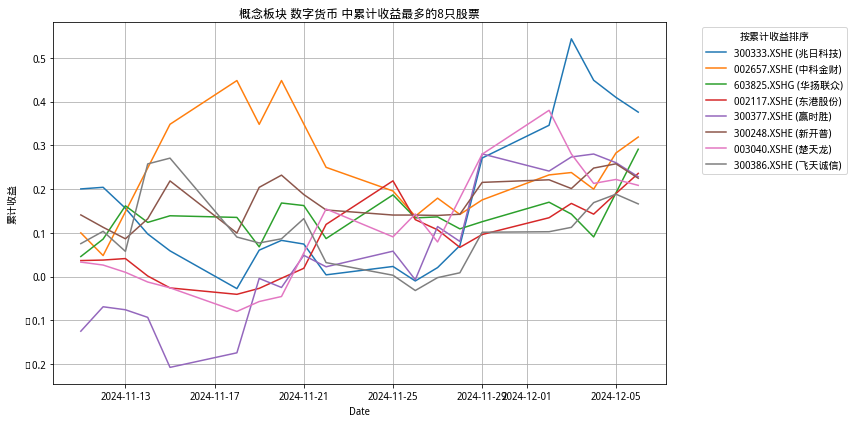

['002657.XSHE',
 '003040.XSHE',
 '603825.XSHG',
 '300333.XSHE',
 '300377.XSHE',
 '002117.XSHE',
 '300386.XSHE',
 '300248.XSHE']

In [26]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('数字货币', end_date=g.end_date, watch_days=N_days, top_N=8)

In [27]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('送转预期', end_date=g.end_date, watch_days=N_days, top_N=8)

没有找到属于 送转预期 的股票（模糊搜索：True）


[]

# 回看过去N天的热点概念

In [28]:
N_days = 10 #看几天？
min_pct_of_attack=5 #只看攻击比例min_pct_of_attack%以上的概念
top_N = 3 #每个热点概念展示几只？

日期: 2024-12-06
攻击家数最多的概念: 文化传媒概念，攻击家数: 19.0


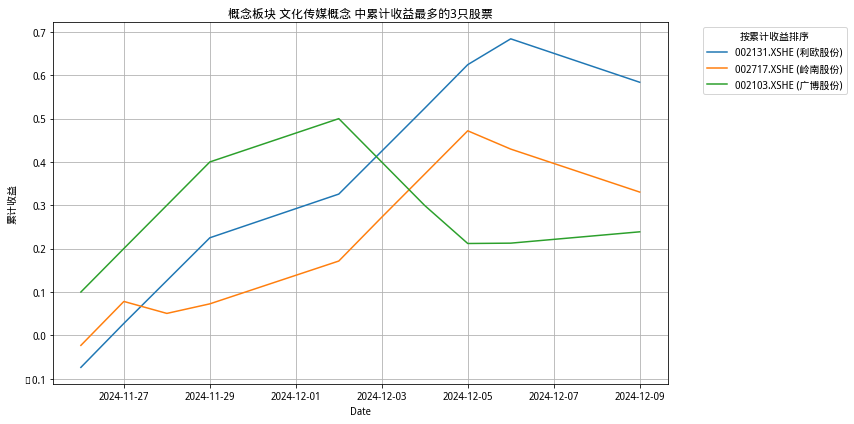

日期: 2024-12-06
攻击比例最高的概念: 文化传媒，攻击比例: 17.44


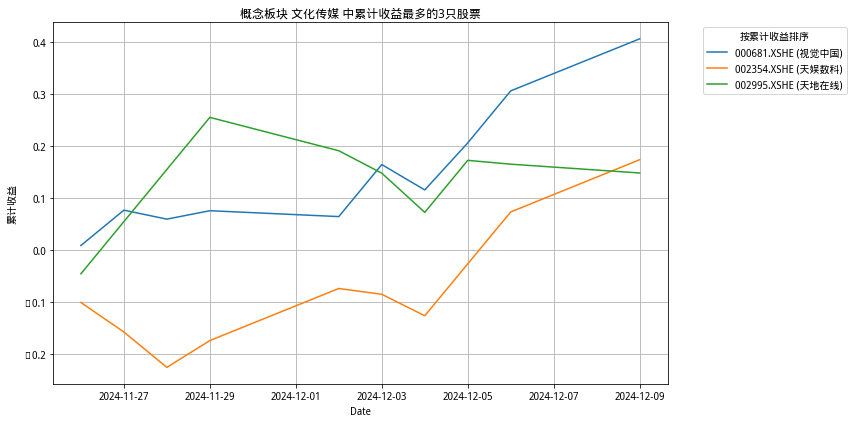

日期: 2024-12-06
攻击比例大于5%的概念: ChatGPT概念，攻击比例: 10.62


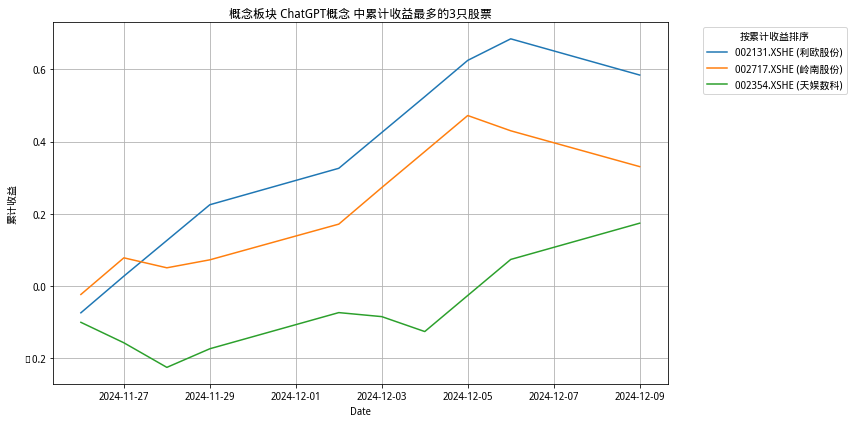

日期: 2024-12-06
攻击比例大于5%的概念: 虚拟数字人，攻击比例: 10.71


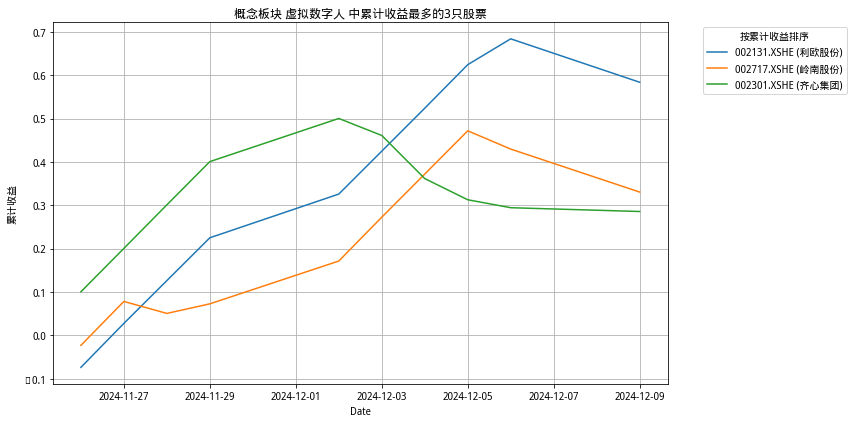

日期: 2024-12-06
攻击比例大于5%的概念: AIGC概念，攻击比例: 8.44


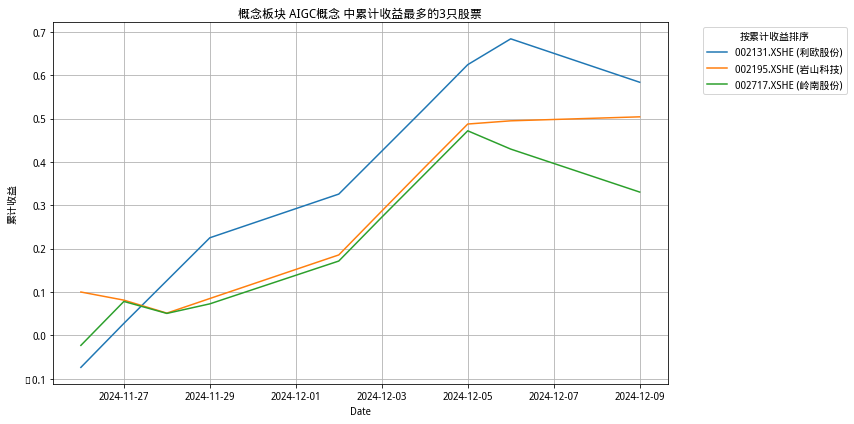

日期: 2024-12-06
攻击比例大于5%的概念: 百度概念，攻击比例: 8.28


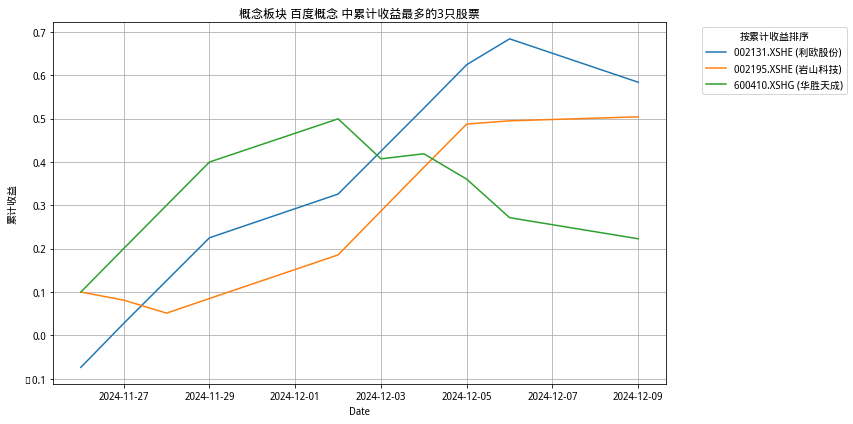

日期: 2024-12-06
攻击比例大于5%的概念: 通用设备，攻击比例: 7.49


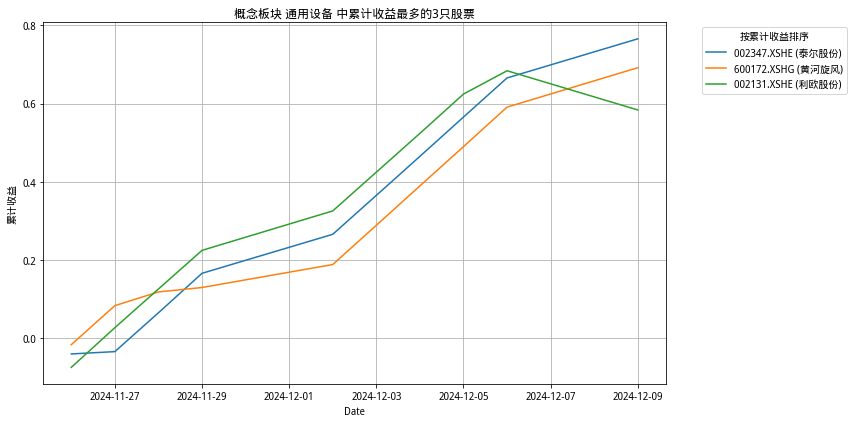

日期: 2024-12-06
攻击比例大于5%的概念: 新型城镇化，攻击比例: 7.78


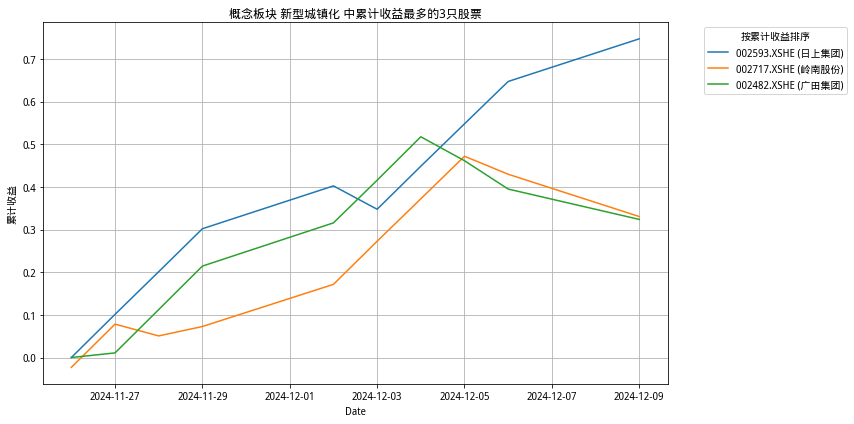

日期: 2024-12-06
攻击比例大于5%的概念: 数据要素，攻击比例: 6.61


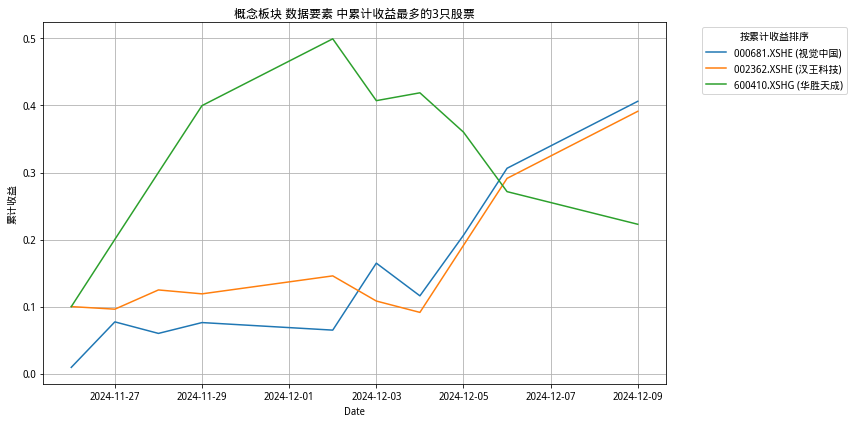

日期: 2024-12-06
攻击比例大于5%的概念: 乡村振兴，攻击比例: 6.62


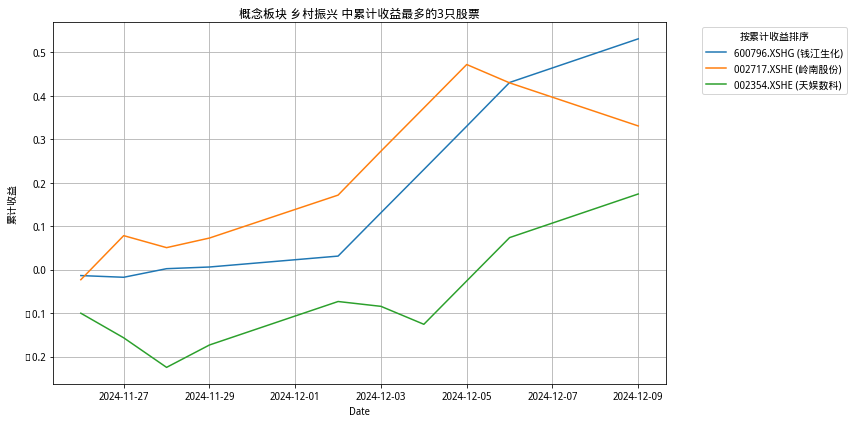

日期: 2024-12-05
攻击比例最高的概念: 抖音概念，攻击比例: 14.84


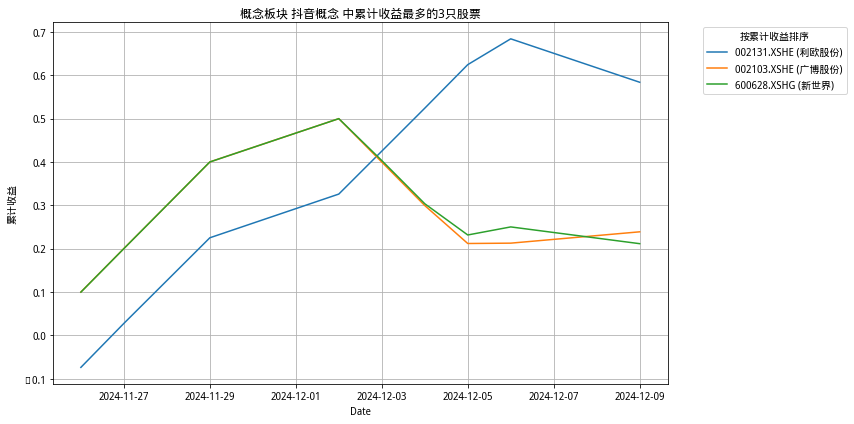

日期: 2024-12-05
攻击比例大于5%的概念: 元宇宙，攻击比例: 10.69


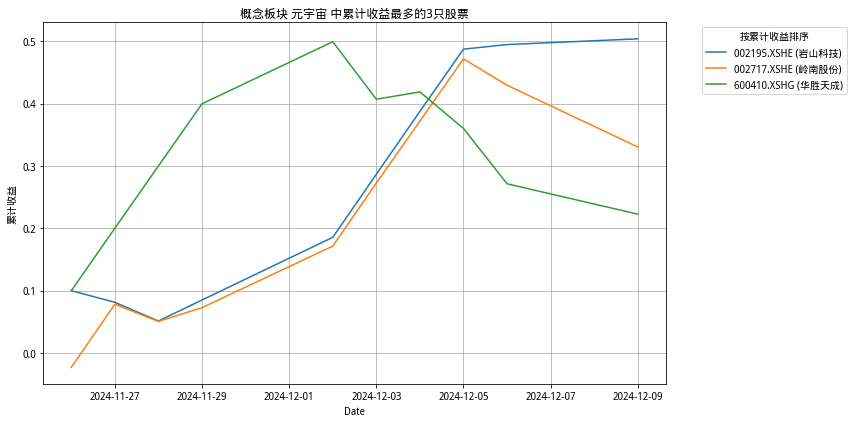

日期: 2024-12-05
攻击比例大于5%的概念: 腾讯概念，攻击比例: 11.46


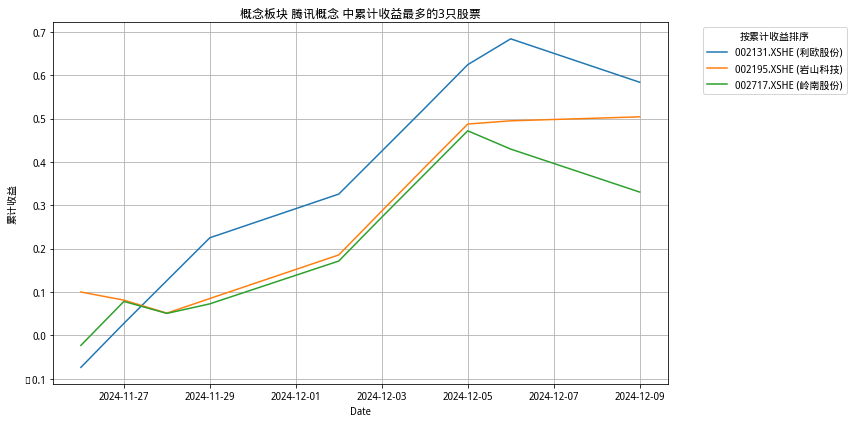

日期: 2024-12-05
攻击比例大于5%的概念: 跨境电商，攻击比例: 7.94


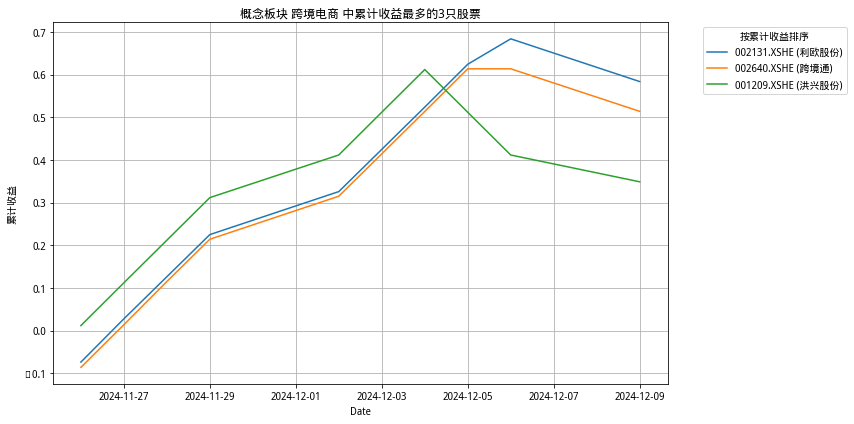

日期: 2024-12-04
攻击比例最高的概念: 减速器，攻击比例: 12.64


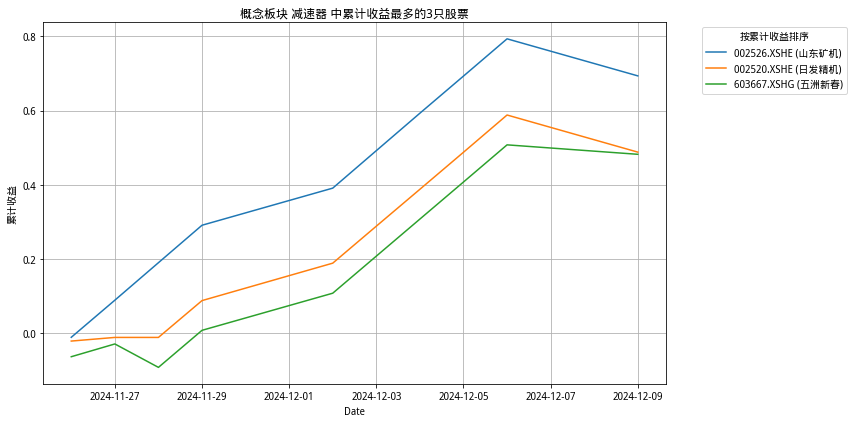

日期: 2024-12-04
攻击比例大于5%的概念: 高端装备，攻击比例: 5.22


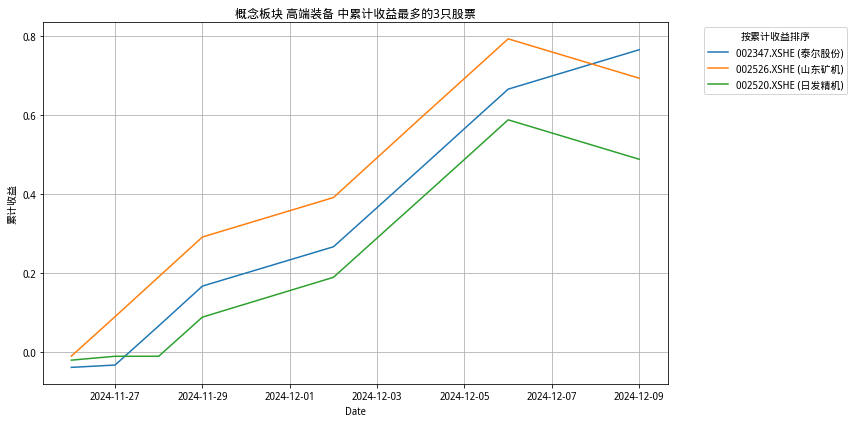

日期: 2024-12-04
攻击比例大于5%的概念: 预制菜，攻击比例: 9.9


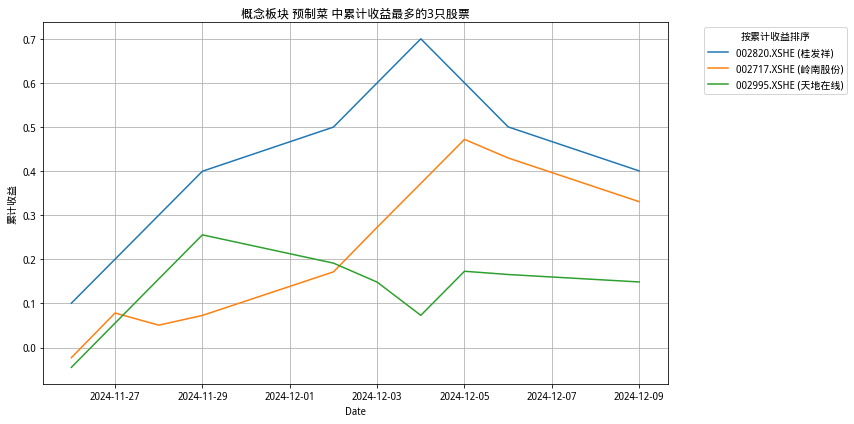

日期: 2024-12-04
攻击比例大于5%的概念: 智能物流，攻击比例: 6.92


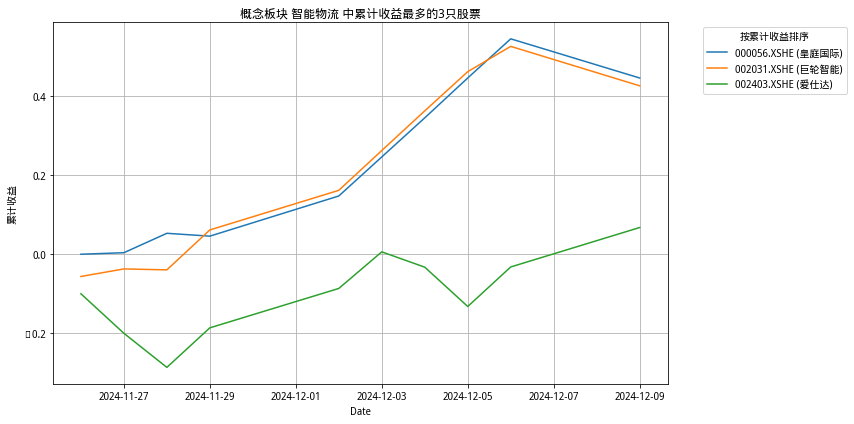

日期: 2024-12-03
攻击比例大于5%的概念: 网络直播，攻击比例: 6.67


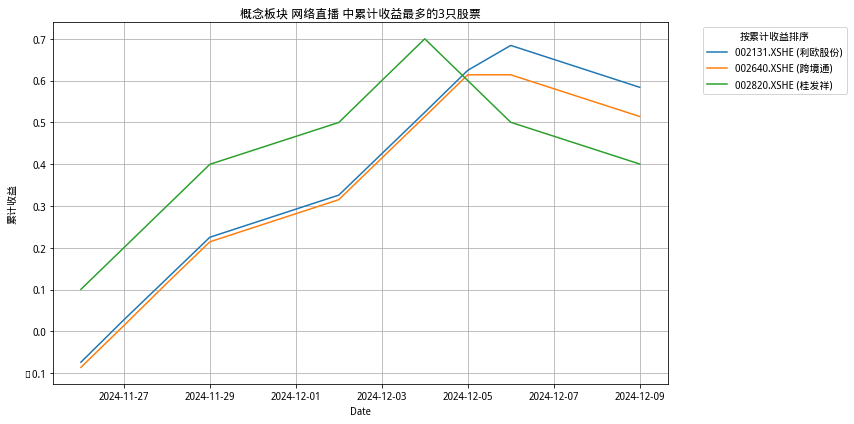

日期: 2024-12-02
攻击比例最高的概念: 海南自贸区，攻击比例: 78.57


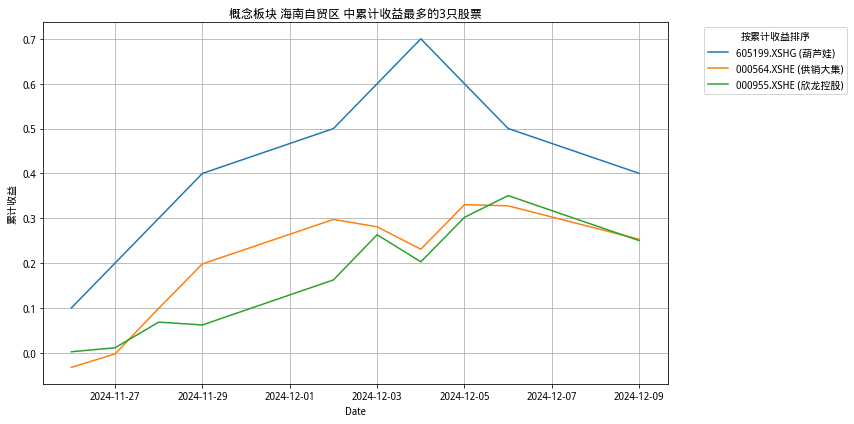

日期: 2024-12-02
攻击比例大于5%的概念: 参股银行，攻击比例: 9.55


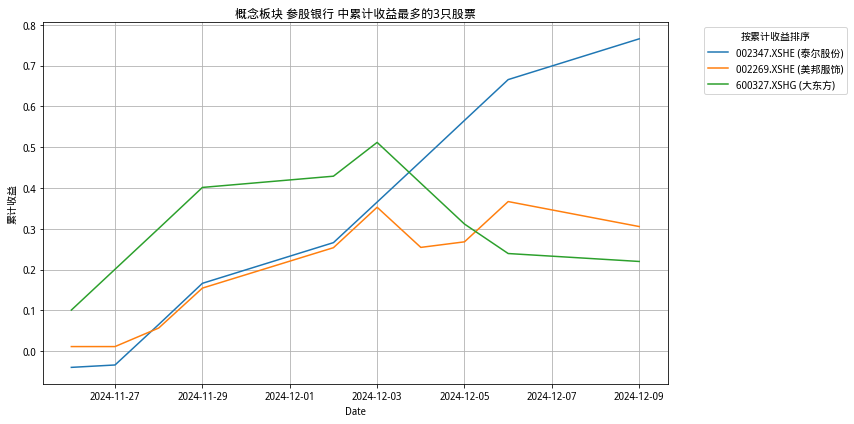

日期: 2024-12-02
攻击比例大于5%的概念: 网红经济，攻击比例: 16.3


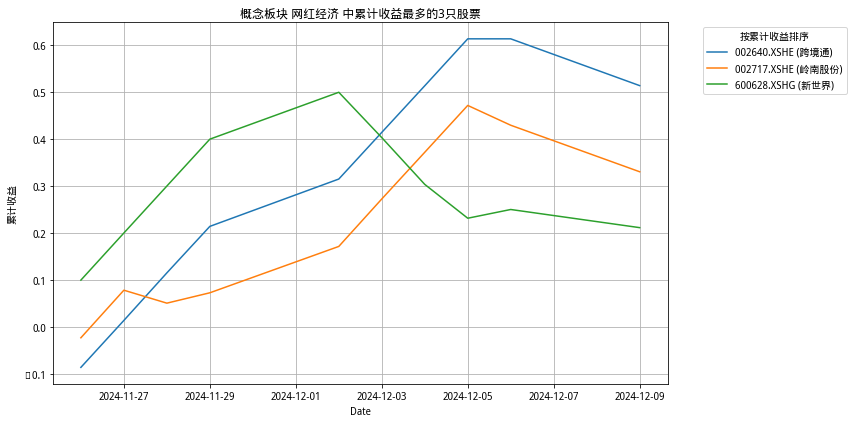

日期: 2024-11-29
攻击比例最高的概念: 人形机器人，攻击比例: 30.36


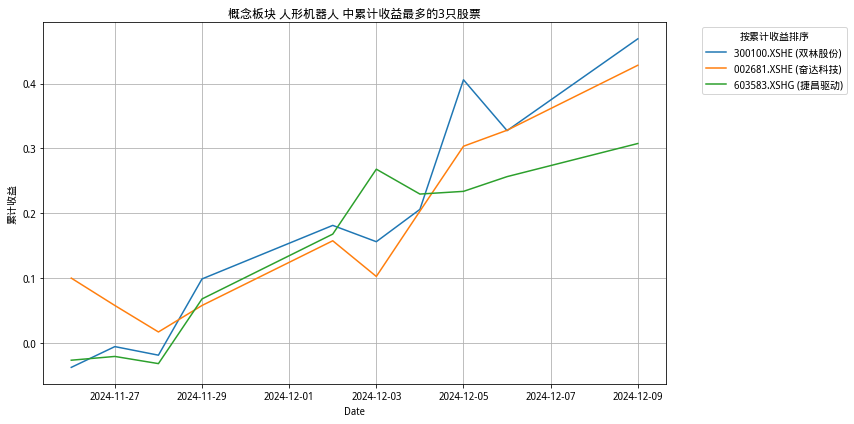

日期: 2024-11-29
攻击比例大于5%的概念: 工业互联网，攻击比例: 7.84


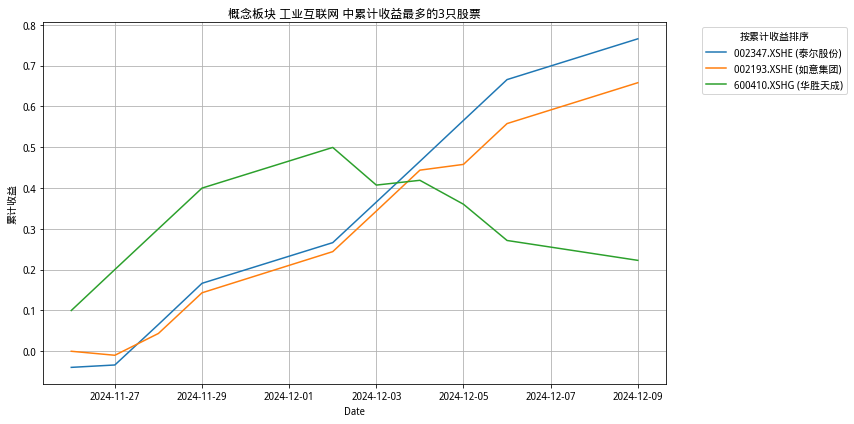

日期: 2024-11-29
攻击比例大于5%的概念: 新型工业化，攻击比例: 11.18


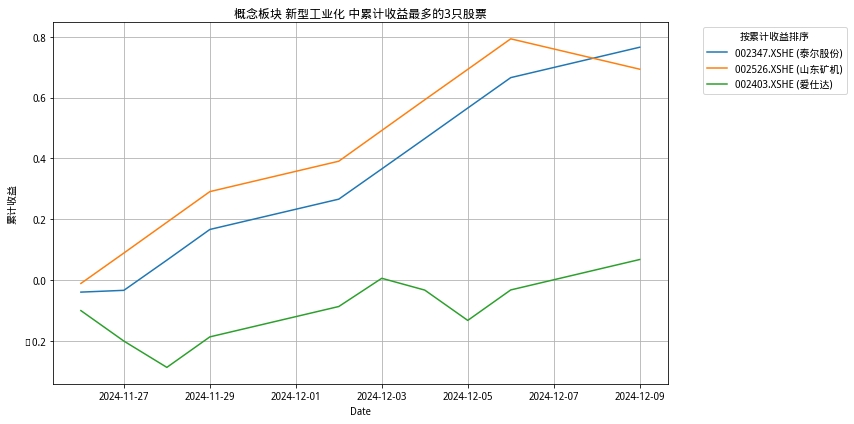

日期: 2024-11-29
攻击比例大于5%的概念: 互联网金融，攻击比例: 9.03


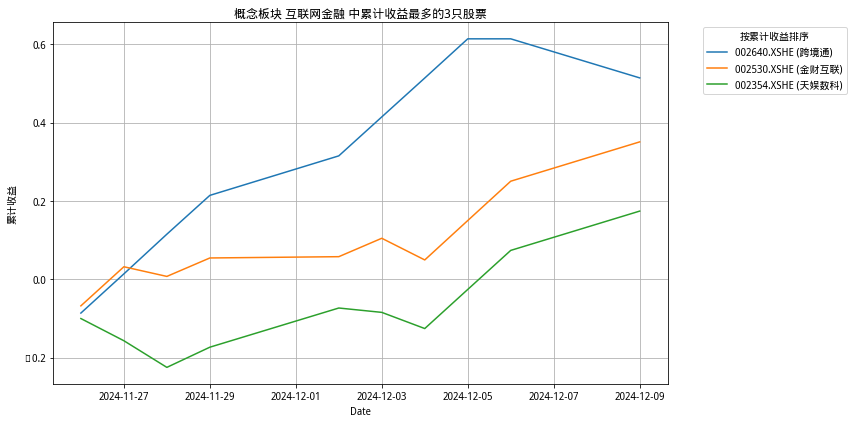

日期: 2024-11-29
攻击比例大于5%的概念: 特斯拉概念，攻击比例: 6.73


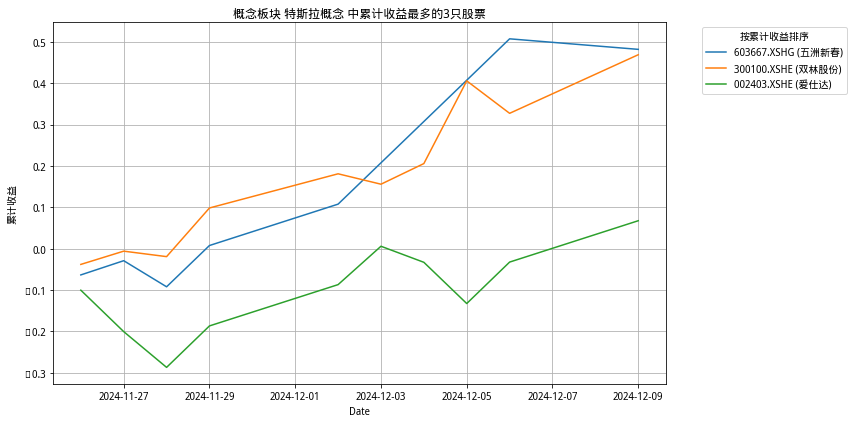

最后10天 热点行业 和 热点概念 成分股的并集为: 35只
002301.XSHE 齐心集团
002354.XSHE 天娱数科
002362.XSHE 汉王科技
002995.XSHE 天地在线
002269.XSHE 美邦服饰
002820.XSHE 桂发祥
000955.XSHE 欣龙控股
002717.XSHE 岭南股份
001209.XSHE 洪兴股份
002193.XSHE 如意集团
002681.XSHE 奋达科技
600628.XSHG 新世界
000056.XSHE 皇庭国际
600410.XSHG 华胜天成
600172.XSHG 黄河旋风
603583.XSHG 捷昌驱动
002031.XSHE 巨轮智能
002403.XSHE 爱仕达
000564.XSHE 供销大集
002526.XSHE 山东矿机
600796.XSHG 钱江生化
000681.XSHE 视觉中国
002530.XSHE 金财互联
002103.XSHE 广博股份
002482.XSHE 广田集团
605199.XSHG 葫芦娃
600327.XSHG 大东方
002195.XSHE 岩山科技
300100.XSHE 双林股份
002520.XSHE 日发精机
002593.XSHE 日上集团
002347.XSHE 泰尔股份
002640.XSHE 跨境通
603667.XSHG 五洲新春
002131.XSHE 利欧股份


In [29]:
#过去g.watch_days中的热点概念大集合，看热点回流？
def find_lead_stocks_in_recent_hot_concepts(df_category_score, N_days=10, top_N=8, min_pct_of_attack = 5, draw_chart=True):
    # 第一步：将 DataFrame 按日期降序排序，从最近一天开始遍历
    df_category_score = df_category_score.sort_values(by='date', ascending=False)

    # 创建一个集合，用于记录已经打印过的概念
    printed_categories = set()

    # 创建一个集合，用于存储所有找到的领涨股
    all_lead_stocks = set()

    # 第二步：遍历每一天的数据，找出得分最高和涨停比例最高的概念
    for date in df_category_score['date'].unique():
        # 筛选出当天的数据
        df_daily = df_category_score[df_category_score['date'] == date]

        # 找到得分最高的概念
        highest_score_concept = df_daily.loc[df_daily['score'].idxmax()]
        highest_score_category = highest_score_concept['category']
        highest_score_value = highest_score_concept['score']

        # 找到涨停比例最高的概念
        highest_pct_attack_concept = df_daily.loc[df_daily['pct_of_attack'].idxmax()]
        highest_pct_attack_category = highest_pct_attack_concept['category']
        highest_pct_attack_value = highest_pct_attack_concept['pct_of_attack']

        # 检查得分最高的概念是否已经打印过
        if highest_score_category not in printed_categories:
            # 打印日期以及得分最高的概念的详细信息
            if draw_chart: print(f"日期: {date}")
            if draw_chart: print(f"攻击家数最多的概念: {highest_score_category}，攻击家数: {highest_score_value}")
            # 调用 lead_stocks_in_category 方法，获取该概念的领涨股
            lead_stocks = category.lead_stocks_in_category(highest_score_category, end_date=g.auc_date, watch_days=N_days, top_N=top_N, fuzzy_match=False, draw_chart=draw_chart)
            # 将找到的股票加入到 all_lead_stocks 集合中
            all_lead_stocks.update(lead_stocks)
            # 将该概念添加到已打印集合中
            printed_categories.add(highest_score_category)

        # 检查涨停比例最高的概念是否已经打印过
        if highest_pct_attack_category not in printed_categories:
            # 打印日期以及涨停比例最高的概念的详细信息
            if draw_chart: print(f"日期: {date}")
            if draw_chart: print(f"攻击比例最高的概念: {highest_pct_attack_category}，攻击比例: {highest_pct_attack_value}")
            # 调用 lead_stocks_in_category 方法，获取该概念的领涨股
            lead_stocks = category.lead_stocks_in_category(highest_pct_attack_category, end_date=g.auc_date, watch_days=N_days, top_N=top_N, fuzzy_match=False, draw_chart=draw_chart)
            # 将找到的股票加入到 all_lead_stocks 集合中
            all_lead_stocks.update(lead_stocks)
            # 将该概念添加到已打印集合中
            printed_categories.add(highest_pct_attack_category)

        # 查找当天所有涨停比例大于 10% 的概念，并打印它们
        df_high_attack = df_daily[df_daily['pct_of_attack'] > min_pct_of_attack]
        for _, row in df_high_attack.iterrows():
            category_name = row['category']
            pct_of_attack = row['pct_of_attack']

            # 如果这个概念没有被打印过，则打印出来
            if category_name not in printed_categories:
                if draw_chart: print(f"日期: {date}")
                if draw_chart: print(f"攻击比例大于{min_pct_of_attack}%的概念: {category_name}，攻击比例: {pct_of_attack}")
                # 调用 lead_stocks_in_category 方法，获取该概念的领涨股
                lead_stocks = category.lead_stocks_in_category(category_name, end_date=g.auc_date, watch_days=N_days, top_N=top_N, fuzzy_match=False, draw_chart=draw_chart)
                # 将找到的股票加入到 all_lead_stocks 集合中
                all_lead_stocks.update(lead_stocks)
                # 将该概念添加到已打印集合中
                printed_categories.add(category_name)

    # 返回所有找到的领涨股（去重后的列表）
    return list(all_lead_stocks)

hot_stocks_in_last_N_days = find_lead_stocks_in_recent_hot_concepts(df_category_score, N_days, top_N, min_pct_of_attack, draw_chart=True)
print(f"最后{N_days}天 热点行业 和 热点概念 成分股的并集为: {len(hot_stocks_in_last_N_days)}只")
#print(f"太多了，如需打印，去掉下面的注释符号#")
for stock in hot_stocks_in_last_N_days: print (stock +' '+ get_stock_name(stock))

# 用大单资金（主动性买入），统计热点行业和热点概念 

资金分析的逻辑： 

1.首先资金分为 大单资金 和 流动资金。  
1.1 大单资金，完整的定义是大笔的主动性买单：起到引导、拉升、或护盘作用，但连续性很差: 
1.1.1 通常是1天流入，3-7天甚至11天流出。  
1.1.2 而且涨停是主力出货最佳时机，很多时候涨停，而大单资金流出。  
对个股来说，只能说明  有是否有主力。  

1.2 流动资金，整体的主动性买盘：数额很小，远小于大单资金；因为有人卖就有人买，有人买就有人卖。

2.概念板块太多，我们希望做到的是，在大资金潜伏时，提前发现即将上涨的板块，并买入潜伏。  

3.再次，如果已经已经买入，我们希望发现大资金出货给散户，即使警觉卖出。  

# <span style="color:red; font-size:24px; font-weight:bold">由于大单数据收盘五点后才有，盘中数据是上一个交易日的 </span> 

In [30]:
# 打印某个列的前五的通用函数
import matplotlib.pyplot as plt

#按全周期排序
def plot_top_5_concepts_in_full_period(df, column, title, top_n=5, top_down=True):
    """
    绘制资金流相关的图表，显示前 top_n 个概念板块的时间序列曲线，legend 中包含成分股数量。
    同时合并并打印每个概念板块的时间序列数据表格，并检查 NaN 值并发出告警。
    展开检查每个成分股在哪些日期存在缺失值。
    :param df: DataFrame，包含数据
    :param column: 字符串，选择要绘制的列
    :param title: 字符串，图表标题
    :param top_down: 布尔值，True 表示找最大值（资金流入），False 表示找最小值（资金流出）
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    # 计算每个类别在所有日期内的最大值
    max_values = df.groupby('category')[column].max()
    
    # 根据 top_down 参数选择资金流入最大或资金流出最多的概念板块
    if top_down:
        top_categories = max_values.nlargest(top_n).index.tolist()
    else:
        top_categories = max_values.nsmallest(top_n).index.tolist()

    # 创建新的列，表示概念板块和成分股数量
    df['category_stock_count'] = df['category'] + " (" + df['stock_count'].astype(str) + " 成分股)"

    # 合并前检查 NaN
    nan_data_pre_merge = df[df.isnull().any(axis=1)]
    if not nan_data_pre_merge.empty:
        print(f"\n告警：{title}合并前包含 NaN 值的记录：")
        print(nan_data_pre_merge)

        # 展开检查每个成分股在哪些日期存在缺失值
        print(f"\n详细检查：{title}包含 NaN 值的成分股和日期：")
        missing_columns = ['net_amount_main', 'total_money']
        for index, row in nan_data_pre_merge.iterrows():
            for col in missing_columns:
                if pd.isnull(row[col]):
                    print(f"告警：股票 {row['code']} 在 {row['date']} 的 {col} 数据缺失。")

    # 合并后的时间序列数据表格，使用 fill_value=0 来避免 NaN，并根据最大值排序
    combined_data_table = df[df['category'].isin(top_categories)].pivot_table(
        index='category', columns='date', values=column, aggfunc='sum', fill_value=0
    ).reindex(top_categories)

    # 设置成分股数量的行标签
    combined_data_table.index = [f"{category} ({df[df['category'] == category]['stock_count'].iloc[0]} 成分股)" 
                                 for category in top_categories]

    # 合并后检查 NaN
    nan_data_post_merge = combined_data_table[combined_data_table.isnull().any(axis=1)]
    if not nan_data_post_merge.empty:
        print(f"\n告警：{title}合并后包含 NaN 值的记录：")
        print(nan_data_post_merge)

    # 打印合并后的表格
    print(f"\n{title} 时间序列数据表格：")
    print(combined_data_table)

    # 绘制每个概念板块随时间变化的曲线
    plt.figure(figsize=(10, 6))

    for category, label in zip(top_categories, combined_data_table.index):
        # 筛选出每个概念板块的时间序列数据
        category_data = df[df['category'] == category]
        
        # 绘制该板块的资金流变化曲线
        plt.plot(category_data['date'], category_data[column], label=label)

    plt.axhline(y=0, color='red', linestyle='--', lw=1.5)  # 添加水平0轴线
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.title(title)
    plt.legend(loc='best')  # 添加图例，标注不同的板块及成分股数量
    plt.xticks(rotation=45)  # 旋转日期标签，以避免重叠
    plt.tight_layout()  # 修正为 plt.tight_layout()，以防止图表元素重叠
    plt.show()

# 示例：绘制大资金流入最多的板块时间序列曲线
#plot_top_5_concepts(df_category_money_flow[df_category_money_flow['net_amount_main'] > 0], 'total_money', 'Top 5 【总资金】流入最多的板块')



def plot_top_5_concepts_in_last_day(df, column, title, top_n=5, top_down=True): 
    """
    绘制资金流相关的图表，显示最新日期大资金流入/流出最多的前 top_n 个概念板块，legend 中包含成分股数量。
    同时打印每个概念板块的时间序列数据表格，并检查 NaN 值并发出告警。
    展开检查每个成分股在哪些日期存在缺失值。
    :param df: DataFrame，包含数据
    :param column: 字符串，选择要绘制的列
    :param title: 字符串，图表标题
    :param top_n: int，选择最多的概念板块数量
    :param top_down: 布尔值，True 表示找最大值（资金流入），False 表示找最小值（资金流出）
    """
    import matplotlib.pyplot as plt

    # 找到最新的有数据日期
    latest_date = df['date'].max()
    df_latest = df[df['date'] == latest_date]

    # 根据 top_down 参数选择大资金流入或流出最多的板块
    if top_down:
        df_latest_sorted = df_latest.nlargest(top_n, column)
    else:
        df_latest_sorted = df_latest.nsmallest(top_n, column)

    top_categories = df_latest_sorted['category'].tolist()

    # 创建新的列，表示概念板块和成分股数量
    df_latest_sorted['category_stock_count'] = df_latest_sorted['category'] + " (" + df_latest_sorted['stock_count'].astype(str) + " 成分股)"

    # 打印当前日期的前 top_n 概念板块数据，并按顺序排列
    combined_data_table = df[df['category'].isin(top_categories)].pivot_table(
        index='category', columns='date', values=column, aggfunc='sum', fill_value=0
    ).reindex(top_categories)

    # 显示成分股数量
    combined_data_table.index = df_latest_sorted['category_stock_count']

    print(f"\n{title} 时间序列数据表格：")
    print(combined_data_table)

    # 绘制每个概念板块随时间变化的曲线
    plt.figure(figsize=(10, 6))

    for category, label in zip(df_latest_sorted['category'], df_latest_sorted['category_stock_count']):
        # 筛选出每个概念板块的时间序列数据
        category_data = df[df['category'] == category]
        
        # 绘制该板块的资金流变化曲线
        plt.plot(category_data['date'], category_data[column], label=label)

    plt.axhline(y=0, color='red', linestyle='--', lw=1.5)  # 添加水平0轴线
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.title(f"{title} - 最新日期: {latest_date}")
    plt.legend(loc='best')  # 添加图例，标注不同的板块及成分股数量
    plt.xticks(rotation=45)  # 旋转日期标签，以避免重叠
    plt.tight_layout()  # 修正为 plt.tight_layout()，以防止图表元素重叠
    plt.show()


# 示例：绘制大资金流入最多的板块时间序列曲线
#plot_top_5_concepts(df_category_money_flow[df_category_money_flow['net_amount_main'] > 0], 'total_money', 'Top 5 【总资金】流入最多的板块')


# 一级行业-资金

In [31]:
# 调用 industry_hierarchy 方法
df_industry_hierarchy = category.industry_hierarchy()

# 提取一级行业并转换为列表
industry_L1_list = df_industry_hierarchy['一级行业'].drop_duplicates().tolist()
# 打印一级行业的列表
print(f"\n一级行业: {industry_L1_list}")

# 提取二级行业并转换为列表
industry_L2_list = df_industry_hierarchy['二级行业'].drop_duplicates().tolist()
# 打印一级行业的列表
print(f"\n二级行业: {industry_L2_list}")

# 提取二级行业并转换为列表
industry_L3_list = df_industry_hierarchy['三级行业'].drop_duplicates().tolist()
# 打印一级行业的列表
print(f"\n三级行业: {industry_L3_list}")


一级行业: ['银行I', '房地产I', '计算机I', '未知', '商业贸易I', '机械设备I', '电气设备I', '建筑装饰I', '建筑材料I', '家用电器I', '纺织服装I', '农林牧渔I', '电子I', '综合I', '公用事业I', '医药生物I', '汽车I', '环保I', '石油石化I', '有色金属I', '通信I', '交通运输I', '传媒I', '非银金融I', '化工I', '休闲服务I', '轻工制造I', '国防军工I', '食品饮料I', '煤炭I', '美容护理I', '钢铁I']

二级行业: ['股份制银行II', '房地产开发II', '软件开发II', '未知', '一般零售II', '运输设备II', '电池II', '基础建设II', '玻璃制造II', '白色家电II', '饰品II', '农产品加工II', '光学光电子II', '电子制造II', '综合II', '电力II', '医药商业II', '汽车零部件II', '专业工程II', 'IT服务II', '环境治理II', '通用机械II', '其他建材II', '房地产服务II', '炼化及贸易II', '工业金属II', '其他电子II', '通信设备II', '计算机设备II', '航运港口II', '航空机场II', '贸易II', '化学制药II', '电视广播II', '工程机械II', '光伏设备II', '证券II', '电网设备II', '水泥制造II', '生物制品II', '家电零部件II', '燃气II', '能源金属II', '多元金融II', '化学纤维II', '农化制品II', '中药II', '酒店餐饮II', '铁路公路II', '旅游及景区II', '造纸II', '医疗服务II', '黄金II', '化学原料II', '地面兵装II', '教育II', '食品加工II', '照明设备II', '军工电子II', '商用车II', '环保设备II', '煤炭开采II', '航空装备II', '化学制品II', '白酒II', '乘用车II', '自动化设备II', '林业II', '广告营销II', '医疗美容II', '物流II', '保险II', '房屋建设II', '冶钢原料II', '金属非金属

In [32]:
#有些行业并没有二级行业，或三级行业 ==> 所以直接统计 二级 或 三级行业并不好。

In [ ]:
#按一级行业汇总资金数据，top_N = 100000意味着全部一级行业都统计
industry_money_flow_df = category.industry_money_flow(end_date=g.end_date, count=g.watch_days, top_N=10000, level=1)

In [ ]:
#一级行业不多，打印来看看（二级行业和概念就不要全部打印了）
last_date=max(industry_money_flow_df['date'])
industry_money_flow_last_date_df=industry_money_flow_df[industry_money_flow_df['date']==last_date]
industry_money_flow_last_date_df_sorted = industry_money_flow_last_date_df.sort_values(by='net_amount_main', ascending=False)
industry_money_flow_last_date_df_sorted

In [ ]:
# 选择 最全部日期 大资金流入最多的 5 个 一级行业
plot_top_5_concepts_in_last_day(industry_money_flow_df, 'net_amount_main', '最后一天 【大单资金】流入最多的行业', top_n=5, top_down=True)

#选择 最全部日期 大资金流出最多的 5 个 一级行业
plot_top_5_concepts_in_last_day(industry_money_flow_df, 'net_amount_main', '最后一天 【大单资金】流出最多的行业', top_n=5, top_down=False)

# 二级行业-资金

In [ ]:
#按二级行业汇总资金数据，top_N = 100000意味着全部二级行业都统计
industry_L2_money_flow_df =  category.industry_money_flow(end_date=g.end_date, count=g.watch_days, top_N=10000, level=2)

In [ ]:
# 选择 最全部日期 大资金流入最多的 5 个概念
plot_top_5_concepts_in_last_day(industry_L2_money_flow_df, 'net_amount_main', '最后一天 【大单资金】流入最多的 二级行业', top_n=5, top_down=True)

#选择 最全部日期 大资金流出最多的 5 个概念
plot_top_5_concepts_in_last_day(industry_L2_money_flow_df, 'net_amount_main', '最后一天 【大单资金】流出最多的 二级行业', top_n=5, top_down=False)

In [ ]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('证券II', end_date=g.end_date, watch_days=10, top_N=8)

# 概念板块-资金打分（注意大资金本来就是不连续的）

In [ ]:
# 假设 category 实例已经包含了概念板块的数据
# 并且 concept_category 是存储概念板块信息的 DataFrame

# 统计唯一的概念板块数量
unique_concepts = category.concept_category['category'].nunique()

# 打印概念板块的数量
print(f"概念板块的总数量为: {unique_concepts}")

# 如果想查看所有的概念板块名称
concept_names = category.concept_category['category'].unique()
print(f"概念板块名称列表为: {concept_names}")


In [ ]:
#按 概念成分股 汇总资金数据
df_category_money_flow = category.category_money_flow(end_date=g.end_date, count=g.watch_days, top_N=10000)
#print(df_category_money_flow.head(20))

In [ ]:
# 找出包含 NaN 的记录
nan_data = df_category_money_flow[df_category_money_flow.isnull().any(axis=1)]
print("包含 NaN 值的记录(没有，则说明数据完全正确）：")
print(nan_data)


# 概念板块-大资金

In [ ]:
# 选择 最后一天 大单资金流入最多的 5 个概念
plot_top_5_concepts_in_last_day(df_category_money_flow, 'net_amount_main', '最后一天 【大单资金】流入最多的板块', top_n=5, top_down=True)

#选择 最后一天  大单资金流出最多的 5 个概念
plot_top_5_concepts_in_last_day(df_category_money_flow, 'net_amount_main', '最后一天 【大单资金】流出最多的板块', top_n=5, top_down=False)

# 概念板块 - 平均每股大资金

In [ ]:
# 选择 最后一天 平均每股【大单资金】流入最多 5 个概念
plot_top_5_concepts_in_last_day(df_category_money_flow, 'avg_big_money_per_stock', '最后一天 平均每股【大单资金】流入最多的板块', top_n=5, top_down=True)

#选择 最后一天  平均每股【大单资金】流出最多 5 个概念
plot_top_5_concepts_in_last_day(df_category_money_flow, 'avg_big_money_per_stock', '最后一天 平均每股【大单资金】流出最多的板块', top_n=5, top_down=False)

In [ ]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('稀土', end_date=g.end_date, watch_days=10, top_N=8)

In [ ]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('华为欧拉', end_date=g.end_date, watch_days=10, top_N=8)

In [ ]:
#选取某个概念，画出攻击次数最高的十只股票走势图，找出其中的龙一，龙二，龙三
category.lead_stocks_in_category('华为昇腾', end_date=g.end_date, watch_days=10, top_N=8)

# 概念-历史上发生过什么？怎么演进的

In [ ]:
# 六、查看某个概念的最高涨停历史，用于找找历史上发生了什么？怎么演进的？

In [ ]:
#通过概念名字，找出概念的成分股，并计算攻击次数和平均涨幅
df_stocks_count_and_avg_change_of_a_category = category.get_stock_count_and_avg_change_of_a_category('房地产开发', count=60)
df_stocks_count_and_avg_change_of_a_category

In [ ]:
df_top_N_days_by_avg_change =  category.get_top_N_days_by_avg_change('房地产开发', days=2400, N=10)

In [ ]:
# 删除不必要的变量，释放内存
#del df_score_zhangting, category, df_concept, pivot_df, top_10_concepts_and_stocks